# Introduction to text embeddings on S&P 500 news
### Course Project — Part 1, Section A

**Pipeline:** S&P 500 tickers → `yfinance` news → structured DataFrame → `all-MiniLM-L6-v2`
embeddings → K-Means clustering → silhouette-based choice of *k* → PCA visualisation →
interpretation of the clusters.

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Retrieve Financial News:**
   - Use the `yfinance` library to gather news headlines for all companies in the S&P 500 index.

2. **Clean and Structure Financial Text Data:**
   - Extract and organize relevant metadata (e.g., ticker, title, summary, publication date, URL) into a structured pandas DataFrame.

3. **Generate Text Embeddings:**
   - Apply a pre-trained sentence transformer model (`all-MiniLM-L6-v2`) to convert news headlines and summaries into numerical embeddings.

4. **Apply Clustering Techniques:**
   - Use K-Means clustering to identify groups of similar news articles based on semantic content.

5. **Determine Optimal Number of Clusters:**
   - Evaluate clustering quality using silhouette scores to find the best number of clusters.

6. **Visualize High-Dimensional Embeddings:**
   - Reduce the embedding space using PCA and visualize clusters in two dimensions.

7. **Interpret Cluster Themes:**
   - Analyze representative news headlines of every cluster and give each group a business-readable label.

## Install and Import important librairies

In [1]:
%pip install --quiet pandas numpy yfinance lxml matplotlib scikit-learn
%pip install --quiet -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 13.8 MB/s eta 0:00:00


In [2]:
%pip install --quiet yellowbrick

In [3]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from yellowbrick.cluster import InterclusterDistance, SilhouetteVisualizer

In [4]:
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import Markdown, display
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_samples, silhouette_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pandas", pd.__version__, "| numpy", np.__version__, "| yfinance", yf.__version__)

pandas 2.2.2 | numpy 2.0.2 | yfinance 0.2.66


## Get the list of stocks in the S&P 500

In [5]:
import requests

# Read and print the stock tickers that make up S&P500
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

response = requests.get(url, headers=headers)
df_tickers = pd.read_html(response.text)[0]

display(df_tickers.head())

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [6]:
ticker_list = df_tickers['Symbol'].tolist()

In [7]:
# Yahoo Finance uses '-' instead of '.' for share classes (BRK.B -> BRK-B)
yahoo_symbols = [t.strip().replace('.', '-') for t in ticker_list]

# Company / sector metadata: used later to check whether the clusters are just sector groupings
meta = (df_tickers.assign(YAHOO_SYMBOL=yahoo_symbols)
                  .set_index('YAHOO_SYMBOL')[['Security', 'GICS Sector']]
                  .rename(columns={'Security': 'COMPANY', 'GICS Sector': 'SECTOR'}))

print(f"S&P 500 constituents: {len(yahoo_symbols)}")
display(meta.head())

S&P 500 constituents: 503


,COMPANY,SECTOR
YAHOO_SYMBOL,,
MMM,3M,Industrials
AOS,A. O. Smith,Industrials
ABT,Abbott Laboratories,Health Care
ABBV,AbbVie,Health Care
ACN,Accenture,Information Technology


## Get the news of all 500 stocks in the S&P 500 Index
Use the yfinance library to retrieve the news of all 500 stocks in the index.
https://ranaroussi.github.io/yfinance/reference/yfinance.stock.html

### Get the news in a dictionary

The `.news` endpoint is queried once per ticker, so this loop makes ~500 HTTP calls. Three
precautions keep it robust:

* every call is wrapped in a `try/except` — a single failing ticker must not kill the whole loop;
* a short pause between calls avoids being throttled by Yahoo;
* newer `yfinance` releases expose `get_news(count=…)` while older ones only expose the `.news`
  property, so we support both.

Expect a non-trivial number of tickers to return an empty list: not every S&P 500 company has news
attached on a given day.

In [8]:
def fetch_news(symbol, count=10, pause=0.15):
    """Return the raw list of news items for one ticker (empty list on failure)."""
    try:
        ticker = yf.Ticker(symbol)
        try:
            items = ticker.get_news(count=count)          # yfinance >= 0.2.5x
        except TypeError:
            items = ticker.news                           # older releases
        return items or []
    except Exception as exc:
        print(f"  [warn] {symbol}: {type(exc).__name__} - {exc}")
        return []
    finally:
        time.sleep(pause)


# Dictionary: key = ticker symbol, value = raw news payload returned by yfinance
news_dict = {}
t0 = time.time()
for i, symbol in enumerate(yahoo_symbols, start=1):
    news_dict[symbol] = fetch_news(symbol)
    if i % 50 == 0:
        collected = sum(len(v) for v in news_dict.values())
        print(f"  {i:>3}/{len(yahoo_symbols)} tickers | {collected} articles | "
              f"{time.time() - t0:.0f}s elapsed")

n_articles = sum(len(v) for v in news_dict.values())
n_empty = sum(1 for v in news_dict.values() if not v)
print(f"\nTickers queried      : {len(news_dict)}")
print(f"Tickers with no news : {n_empty}")
print(f"Raw articles collected: {n_articles}")

   50/503 tickers | 500 articles | 16s elapsed
  100/503 tickers | 1000 articles | 32s elapsed
  150/503 tickers | 1500 articles | 47s elapsed
  200/503 tickers | 2000 articles | 63s elapsed
  250/503 tickers | 2500 articles | 78s elapsed
  300/503 tickers | 3000 articles | 93s elapsed
  350/503 tickers | 3500 articles | 109s elapsed
  400/503 tickers | 4000 articles | 125s elapsed
  450/503 tickers | 4500 articles | 141s elapsed
  500/503 tickers | 5000 articles | 156s elapsed

Tickers queried      : 503
Tickers with no news : 0
Raw articles collected: 5030


In [9]:
# What does one raw item actually look like? (useful to know which keys to extract)
sample_symbol = next(s for s, v in news_dict.items() if v)
sample_item = news_dict[sample_symbol][0]
print("Sample ticker:", sample_symbol)
print("Top-level keys:", list(sample_item.keys()))
if 'content' in sample_item:
    print("content keys :", list(sample_item['content'].keys()))
sample_item

Sample ticker: MMM
Top-level keys: ['id', 'content']
content keys : ['id', 'contentType', 'title', 'description', 'summary', 'pubDate', 'displayTime', 'isHosted', 'bypassModal', 'previewUrl', 'thumbnail', 'provider', 'canonicalUrl', 'clickThroughUrl', 'metadata', 'finance', 'storyline']


{'id': 'ddb17a1d-4ff6-3705-a55b-64606e58675b',
 'content': {'id': 'ddb17a1d-4ff6-3705-a55b-64606e58675b',
  'contentType': 'STORY',
  'title': 'Industrial Giant Sees Insider Selling, According to Latest SEC Filing',
  'description': '',
  'summary': 'Kevin H. Rhodes exercised options at $154.69 per share and immediately liquidated the position in open market trading, reducing his direct equity stake by 15%.',
  'pubDate': '2026-07-31T22:40:01Z',
  'displayTime': '2026-07-31T22:40:01Z',
  'isHosted': True,
  'bypassModal': False,
  'previewUrl': None,
  'thumbnail': {'originalUrl': 'https://media.zenfs.com/en/motleyfool.com/5a440778ac8f2b72736c872664e8a572',
   'originalWidth': 800,
   'originalHeight': 714,
   'caption': '',
   'resolutions': [{'url': 'https://s.yimg.com/uu/api/res/1.2/Z.2h1QPR_hfwjCgv_xQ4Bw--~B/aD03MTQ7dz04MDA7YXBwaWQ9eXRhY2h5b24-/https://media.zenfs.com/en/motleyfool.com/5a440778ac8f2b72736c872664e8a572',
     'width': 800,
     'height': 714,
     'tag': 'original'}

### Structure the news into a pandas dataframe

Your final dataframe should have the following columns:
- TICKER
- TITLE (of the news)
- SUMMARY (of the news)
- PUBLICATION_DATE (of the news)
- URL (of the news)

Note: all of those fields are provided in the yfinance news component. Refer to the library documentation.

**Two payload schemas.** Recent `yfinance` versions nest everything under `content`
(`content.title`, `content.summary`, `content.pubDate`, `content.canonicalUrl.url`,
`content.provider.displayName`), while older versions return a flat dictionary
(`title`, `publisher`, `link`, `providerPublishTime` as a UNIX timestamp). The parser below handles
both so the notebook does not break when the library is upgraded.

In [10]:
def _first(dct, *keys):
    """Return the first non-empty value among `keys`."""
    for k in keys:
        value = dct.get(k)
        if value:
            return value
    return None


def parse_article(symbol, item):
    """Flatten one raw yfinance news item into a record with the required columns."""
    content = item.get('content', item)                   # new schema nests under 'content'

    title = _first(content, 'title', 'headline')
    summary = _first(content, 'summary', 'description', 'shortDescription')

    # URL: new schema -> canonicalUrl/clickThroughUrl dicts; old schema -> 'link'
    url = None
    for key in ('canonicalUrl', 'clickThroughUrl'):
        node = content.get(key)
        if isinstance(node, dict) and node.get('url'):
            url = node['url']
            break
    url = url or _first(content, 'link', 'url')

    # Provider: new schema -> provider.displayName; old schema -> 'publisher'
    provider = content.get('provider')
    provider = provider.get('displayName') if isinstance(provider, dict) else provider
    provider = provider or _first(content, 'publisher', 'providerDisplayName')

    published = _first(content, 'pubDate', 'displayTime', 'providerPublishTime')

    return {
        'TICKER': symbol,
        'TITLE': title,
        'SUMMARY': summary,
        'PUBLICATION_DATE': published,
        'URL': url,
        'PROVIDER': provider,
        'ARTICLE_ID': item.get('id') or _first(content, 'id', 'uuid'),
    }


records = [parse_article(symbol, item)
           for symbol, items in news_dict.items()
           for item in items]

df_news_raw = pd.DataFrame(records)
print(f"Raw news DataFrame: {df_news_raw.shape[0]} rows x {df_news_raw.shape[1]} columns")
display(df_news_raw.head())

Raw news DataFrame: 5030 rows x 7 columns


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER,ARTICLE_ID
0,MMM,"Industrial Giant Sees Insider Selling, According to Latest SEC Filing",Kevin H. Rhodes exercised options at $154.69 per share and immediately liquidated the ...,2026-07-31T22:40:01Z,https://www.fool.com/coverage/filings/2026/07/31/industrial-giant-sees-insider-selling...,Motley Fool,ddb17a1d-4ff6-3705-a55b-64606e58675b
1,MMM,"CSL Q2 Earnings Beat Estimates on Record Sales, Outlook Raised","Carlisle tops Q2 earnings and revenue estimates, posts record sales and raises its 202...",2026-07-30T15:38:00Z,https://finance.yahoo.com/markets/stocks/articles/csl-q2-earnings-beat-estimates-15380...,Zacks,381e1cf1-30a9-378b-9482-050124f86b2b
2,MMM,Five Below and Whirlpool have been highlighted as Zacks Bull and Bear of the Day,"Five Below delivered strong sales growth and raised guidance, while Whirlpool faced we...",2026-07-30T12:48:00Z,https://finance.yahoo.com/markets/stocks/articles/five-below-whirlpool-highlighted-zac...,Zacks,02301a68-4096-3afb-b45d-1d45d1b12094
3,MMM,Buy These 3 Blue-Chip Stocks After Strong Q2 2026 Earnings Results,"MMM, TRV and UNH posted strong Q2 results, with higher guidance, investment strength a...",2026-07-29T13:06:00Z,https://finance.yahoo.com/markets/stocks/articles/buy-3-blue-chip-stocks-130600697.html,Zacks,706ffa62-987f-32e0-89ff-7656c0a28d11
4,MMM,"Beat the Market Like Zacks: Monster Beverage, Carpenter Tech, Usio in Focus","MNST, CRS and USIO highlight Zacks strategies that outperformed amid a volatile market.",2026-07-27T12:15:00Z,https://finance.yahoo.com/markets/stocks/articles/beat-market-zacks-monster-beverage-1...,Zacks,0e207be0-b3b5-3cd7-a7d7-12aec046738b


In [11]:
# --- Cleaning ---------------------------------------------------------------------------------
df_news = df_news_raw.copy()
before = len(df_news)

# 1. Publication date -> timezone-aware datetime (epoch seconds in the legacy schema)
def to_datetime(value):
    if pd.isna(value):
        return pd.NaT
    if isinstance(value, (int, float)) or (isinstance(value, str) and str(value).isdigit()):
        return pd.to_datetime(float(value), unit='s', utc=True)
    return pd.to_datetime(value, utc=True, errors='coerce')

df_news['PUBLICATION_DATE'] = df_news['PUBLICATION_DATE'].apply(to_datetime)

# 2. Normalise the text fields
for col in ['TITLE', 'SUMMARY', 'PROVIDER']:
    df_news[col] = (df_news[col].astype('string')
                                .str.replace(r'\s+', ' ', regex=True)
                                .str.strip())

# 3. A row without a title is unusable (the title is what we embed)
df_news = df_news[df_news['TITLE'].notna() & (df_news['TITLE'].str.len() >= 10)]

# 4. Drop duplicates: the same article is often attached to several tickers
df_news = df_news.drop_duplicates(subset=['TICKER', 'TITLE'])

# 5. Missing summaries: keep the row, flag it, and fall back to the title
df_news['HAS_SUMMARY'] = df_news['SUMMARY'].notna()
df_news['SUMMARY'] = df_news['SUMMARY'].fillna(df_news['TITLE'])

df_news = (df_news.sort_values(['TICKER', 'PUBLICATION_DATE'], ascending=[True, False])
                  .reset_index(drop=True))

print(f"Rows before cleaning : {before}")
print(f"Rows after cleaning  : {len(df_news)}")
print(f"Unique tickers       : {df_news['TICKER'].nunique()}")
print(f"Articles per ticker  : mean {len(df_news) / df_news['TICKER'].nunique():.1f}")
print(f"Rows without a real summary: {(~df_news['HAS_SUMMARY']).sum()}")

Rows before cleaning : 5030
Rows after cleaning  : 5030
Unique tickers       : 503
Articles per ticker  : mean 10.0
Rows without a real summary: 0


In [12]:
df_news = df_news[['TICKER', 'TITLE', 'SUMMARY', 'PUBLICATION_DATE', 'URL', 'PROVIDER',
                   'ARTICLE_ID', 'HAS_SUMMARY']]
display(df_news.head(10))
df_news.info()

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,URL,PROVIDER,ARTICLE_ID,HAS_SUMMARY
0,A,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,"TMO is expanding bioproduction, AI tools and clinical data capabilities, but execution...",2026-07-31 13:20:00+00:00,https://finance.yahoo.com/healthcare/articles/thermo-fisher-riding-bioproduction-ai-13...,Zacks,7bfc067b-d8ce-32c0-9ad8-eb33e1441230,True
1,A,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,"Stryker (SYK) delivered earnings and revenue surprises of +6.65% and +0.48%, respectiv...",2026-07-30 21:25:04+00:00,https://finance.yahoo.com/markets/stocks/articles/stryker-syk-q2-earnings-revenues-212...,Zacks,050ce149-82a0-37ff-b5cc-5cf8b0a80478,True
2,A,Avantor Stock Surged Because One Segment Stopped Shrinking,"Organic revenue still fell, yet a segment returning to growth and a raised outlook wer...",2026-07-30 18:29:59+00:00,https://www.trefis.com/articles/609518/avantor-stock-surged-because-one-segment-stoppe...,Trefis,851e32cd-f97d-3184-ae96-51d2ee93da43,True
3,A,Revvity to Report Q2 Earnings: What's in Store for the Stock?,RVTY heads into Q2 earnings with improving Life Sciences demand and resilient Diagnost...,2026-07-30 16:40:00+00:00,https://finance.yahoo.com/markets/stocks/articles/revvity-report-q2-earnings-whats-164...,Zacks,691cfb75-653a-3318-bb6b-343e22851734,True
4,A,"Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down",PHG lifts its 2026 profit and free cash flow outlook after Q2 earnings increase on hig...,2026-07-29 18:01:00+00:00,https://finance.yahoo.com/markets/stocks/articles/philips-q2-earnings-revenues-increas...,Zacks,24f16baa-2531-3b83-9933-33b4d4e54948,True
5,A,Is Argenx (ARGX) Outperforming Other Medical Stocks This Year?,Here is how argenex SE (ARGX) and Agilent Technologies (A) have performed compared to ...,2026-07-29 13:40:03+00:00,https://finance.yahoo.com/markets/stocks/articles/argenx-argx-outperforming-other-medi...,Zacks,641bd0b3-a871-3b2c-a277-04cf4037f7b5,True
6,A,Stryker's Q2 Results Likely to Reflect Recovery of Q1 Deferred Orders,"SYK heads into Q2 with robotic surgery momentum, deferred revenue recovery and strong ...",2026-07-27 13:01:00+00:00,https://finance.yahoo.com/healthcare/articles/strykers-q2-results-likely-reflect-13010...,Zacks,f809b601-1be2-3ec8-a453-4034961d08f0,True
7,A,DXCM Q2 Results Likely to Reflect Strong G7 & Reimbursement Expansion,"DXCM's Q2 results may reflect strong G7 15 Day adoption, broader reimbursement, and ex...",2026-07-27 13:00:00+00:00,https://finance.yahoo.com/healthcare/articles/dxcm-q2-results-likely-reflect-130000302...,Zacks,5d1a361d-d3db-3701-9892-c669128d42ee,True
8,A,Is Agilent Technologies (A) Undervalued Following Its FDA Approval For OPDIVO Companio...,Agilent Technologies (A) has drawn fresh attention after receiving U.S. Food and Drug ...,2026-07-25 21:16:22+00:00,https://finance.yahoo.com/markets/stocks/articles/agilent-technologies-undervalued-fol...,Simply Wall St.,68c0570a-4367-33aa-a0bc-8b2e79a5bffc,True
9,A,Why Agilent Technologies (A) Is Up 5.4% After New FDA Nod For OPDIVO Cancer Test,"In July 2026, Agilent Technologies received U.S. Food and Drug Administration approval...",2026-07-25 15:12:50+00:00,https://finance.yahoo.com/healthcare/articles/why-agilent-technologies-5-4-151250552.html,Simply Wall St.,18d24be7-76de-3bac-9a0a-58e4ebdf9d60,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5030 entries, 0 to 5029
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   TICKER            5030 non-null   object             
 1   TITLE             5030 non-null   string             
 2   SUMMARY           5030 non-null   string             
 3   PUBLICATION_DATE  5030 non-null   datetime64[ns, UTC]
 4   URL               5030 non-null   object             
 5   PROVIDER          5030 non-null   string             
 6   ARTICLE_ID        5030 non-null   object             
 7   HAS_SUMMARY       5030 non-null   bool               
dtypes: bool(1), datetime64[ns, UTC](1), object(3), string(3)
memory usage: 280.1+ KB


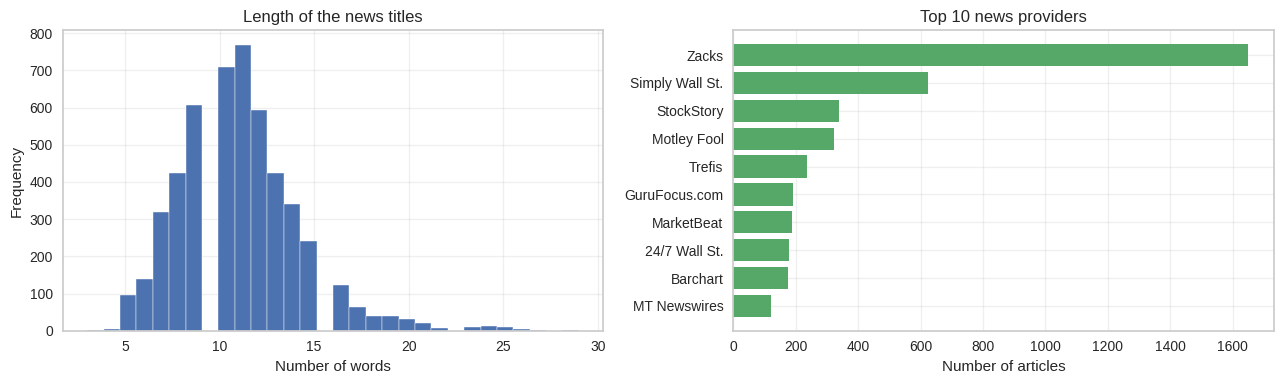

Publication dates range from 2026-03-18 15:50:58+00:00 to 2026-08-02 19:13:00+00:00


In [13]:
# Quick descriptive checks on the corpus we are about to embed
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_news['TITLE'].str.split().str.len().plot(kind='hist', bins=30, ax=axes[0],
                                            color='#4c72b0', edgecolor='white')
axes[0].set_title('Length of the news titles')
axes[0].set_xlabel('Number of words')

top_providers = df_news['PROVIDER'].value_counts().head(10)
axes[1].barh(top_providers.index[::-1].astype(str), top_providers.values[::-1], color='#55a868')
axes[1].set_title('Top 10 news providers')
axes[1].set_xlabel('Number of articles')

plt.tight_layout()
plt.show()

if df_news['PUBLICATION_DATE'].notna().any():
    print("Publication dates range from "
          f"{df_news['PUBLICATION_DATE'].min()} to {df_news['PUBLICATION_DATE'].max()}")

## Exploring text embeddings

- Use the open-source model: 'sentence-transformers/all-MiniLM-L6-v2' to create embeddings on the news title and summary
- Add a column to your news dataframe called EMBEDDED_TEXT using ONLY the TITLE of the news
- Add a column to your news dataframe called EMBEDDINGS, which contains the embedding of EMBEDDED_TEXT

`all-MiniLM-L6-v2` is a 6-layer distilled transformer that maps a sentence to a **384-dimensional**
vector, trained so that semantically similar sentences end up close to each other under cosine
similarity. It truncates inputs at 256 word-pieces — irrelevant here, since news titles are ~10–20
words.

In [14]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(model)
print("Embedding dimension:", model.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)
Embedding dimension: 384


In [15]:
# EMBEDDED_TEXT = the news TITLE only (as required)
df_news['EMBEDDED_TEXT'] = df_news['TITLE'].astype(str).str.strip()

embeddings = model.encode(df_news['EMBEDDED_TEXT'].tolist(),
                          batch_size=64,
                          show_progress_bar=True,
                          convert_to_numpy=True)

df_news['EMBEDDINGS'] = list(embeddings)

print(f"Embeddings matrix: {embeddings.shape}  (rows = articles, columns = dimensions)")
display(df_news[['TICKER', 'TITLE', 'EMBEDDED_TEXT', 'EMBEDDINGS']].head())

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Embeddings matrix: (5030, 384)  (rows = articles, columns = dimensions)


,TICKER,TITLE,EMBEDDED_TEXT,EMBEDDINGS
0,A,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,"[-0.046655934, -0.046706494, -0.029965715, 0.013323064, 0.061135408, 0.07120217, -0.07..."
1,A,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,Stryker (SYK) Q2 Earnings and Revenues Beat Estimates,"[-0.011897913, 0.018847344, -0.016226808, -0.03954951, -0.035370503, -0.038789798, 0.0..."
2,A,Avantor Stock Surged Because One Segment Stopped Shrinking,Avantor Stock Surged Because One Segment Stopped Shrinking,"[-0.012856156, -0.006029089, 0.046524283, 0.011211433, 0.06474187, -0.040015563, -0.06..."
3,A,Revvity to Report Q2 Earnings: What's in Store for the Stock?,Revvity to Report Q2 Earnings: What's in Store for the Stock?,"[-0.03479537, 0.03881338, -0.015764307, 0.06187697, -0.08389846, 0.037871663, -0.02300..."
4,A,"Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down","Philips Q2 Earnings and Revenues Increase Year over Year, Shares Down","[0.040547386, 0.008779844, 0.0667828, -0.0026544433, -0.030840565, -0.0072850017, -0.0..."


In [16]:
# Sanity check: does the embedding space actually capture meaning?
# The two most similar titles in a random sample should be semantically related.
from sklearn.metrics.pairwise import cosine_similarity

sample = df_news.sample(min(200, len(df_news)), random_state=RANDOM_STATE).reset_index(drop=True)
sim = cosine_similarity(np.vstack(sample['EMBEDDINGS'].to_numpy()))
np.fill_diagonal(sim, -1)
i, j = np.unravel_index(sim.argmax(), sim.shape)

print(f"Highest cosine similarity in the sample: {sim[i, j]:.3f}")
print(f"  A ({sample.loc[i, 'TICKER']}): {sample.loc[i, 'TITLE']}")
print(f"  B ({sample.loc[j, 'TICKER']}): {sample.loc[j, 'TITLE']}")

Highest cosine similarity in the sample: 0.803
  A (MCHP): What Are Wall Street Analysts' Target Price for Microchip Technology Stock?
  B (BSX): What Are Wall Street Analysts' Target Price for Boston Scientific Stock?


## Using K-means clustering on news embeddings
to simplify, keep only one news for each company (ticker), you should have 500 rows in your news dataframe

> **Why the result may be slightly under 500 rows.** One row per ticker is exactly what the cell below
> produces, but `.news` returns an empty list for some constituents on any given day (recent IPOs,
> quiet small caps, transient API failures). The number of rows is therefore
> *the number of tickers that actually had at least one usable article* — reported explicitly below,
> together with the coverage ratio, rather than silently padded to 500.

In [17]:
# Keep the MOST RECENT article of each ticker -> one row per company
df_news_unique = (df_news.sort_values(['TICKER', 'PUBLICATION_DATE'], ascending=[True, False])
                         .drop_duplicates(subset='TICKER', keep='first')
                         .reset_index(drop=True))

df_news_unique['COMPANY'] = df_news_unique['TICKER'].map(meta['COMPANY'])
df_news_unique['SECTOR'] = df_news_unique['TICKER'].map(meta['SECTOR'])

X = np.vstack(df_news_unique['EMBEDDINGS'].to_numpy())

print(f"df_news_unique: {df_news_unique.shape[0]} rows (one news per ticker)")
print(f"Coverage: {df_news_unique.shape[0]}/{len(yahoo_symbols)} constituents "
      f"({df_news_unique.shape[0] / len(yahoo_symbols):.1%}) returned at least one usable article")
print(f"Embedding matrix X: {X.shape}")
display(df_news_unique[['TICKER', 'COMPANY', 'SECTOR', 'TITLE', 'PUBLICATION_DATE']].head(10))

df_news_unique: 503 rows (one news per ticker)
Coverage: 503/503 constituents (100.0%) returned at least one usable article
Embedding matrix X: (503, 384)


,TICKER,COMPANY,SECTOR,TITLE,PUBLICATION_DATE
0,A,Agilent Technologies,Health Care,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,2026-07-31 13:20:00+00:00
1,AAPL,Apple Inc.,Information Technology,Big Tech’s $2 trillion AI shakeout just changed everything,2026-08-02 18:33:00+00:00
2,ABBV,AbbVie,Health Care,Why AbbVie Stock Slumped Today,2026-08-01 00:01:21+00:00
3,ABNB,Airbnb,Consumer Discretionary,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,2026-07-31 23:24:00+00:00
4,ABT,Abbott Laboratories,Health Care,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2026-08-02 17:14:20+00:00
5,ACGL,Arch Capital Group,Financials,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2026-08-01 12:12:09+00:00
6,ACN,Accenture,Information Technology,What ACN Holders Got Paid While The Stock Fell Behind,2026-08-01 15:01:50+00:00
7,ADBE,Adobe Inc.,Information Technology,Why ADSK Stock Hands You So Much Cash Right Now,2026-08-01 16:22:53+00:00
8,ADI,Analog Devices,Information Technology,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,2026-07-31 14:04:00+00:00
9,ADM,Archer Daniels Midland,Consumer Staples,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,2026-08-02 04:16:12+00:00


### Identify the number of clusters using the silhouette score

- Using a for loop, do the clustering with different k values (number of clusters), test 1 to 6 clusters
- Compute the silhouette score for every k value
- Plot the silhouette score for different k values

#### Try different values of k and compute silhouette scores

> **Note on k = 1.** The silhouette score of an observation compares its average distance to its own
> cluster with its average distance to the *nearest other* cluster. With a single cluster there is no
> "other cluster", so the score is mathematically undefined (`scikit-learn` raises a `ValueError` for
> `n_labels = 1`). The loop therefore runs over **k = 2 … 6**, which is also the range required by the
> assignment brief.

In [18]:
k_values = range(2, 7)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    rows.append({
        'K': k,
        'SILHOUETTE': score,
        'INERTIA': km.inertia_,
        'SMALLEST_CLUSTER': int(np.bincount(labels).min()),
        'LARGEST_CLUSTER': int(np.bincount(labels).max()),
    })
    print(f"k = {k} | silhouette = {score:.4f} | inertia = {km.inertia_:,.0f} | "
          f"cluster sizes = {np.bincount(labels).tolist()}")

df_silhouette = pd.DataFrame(rows)
display(df_silhouette.style.format({'SILHOUETTE': '{:.4f}', 'INERTIA': '{:,.0f}'}))

k = 2 | silhouette = 0.0321 | inertia = 367 | cluster sizes = [358, 145]
k = 3 | silhouette = 0.0373 | inertia = 356 | cluster sizes = [132, 150, 221]
k = 4 | silhouette = 0.0329 | inertia = 351 | cluster sizes = [122, 144, 124, 113]
k = 5 | silhouette = 0.0199 | inertia = 346 | cluster sizes = [72, 104, 112, 71, 144]
k = 6 | silhouette = 0.0216 | inertia = 342 | cluster sizes = [67, 95, 130, 62, 63, 86]


,K,SILHOUETTE,INERTIA,SMALLEST_CLUSTER,LARGEST_CLUSTER
0,2,0.0321,367,145,358
1,3,0.0373,356,132,221
2,4,0.0329,351,113,144
3,5,0.0199,346,71,144
4,6,0.0216,342,62,130


In [19]:
k_values = range(2, 7)
rows = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    score_silhouette = silhouette_score(X, labels)
    score_davies_bouldin = davies_bouldin_score(X, labels)
    score_calinski_harabasz = calinski_harabasz_score(X, labels)
    rows.append({
        'K': k,
        'SILHOUETTE': score_silhouette,
        'DAVIES_BOULDIN': score_davies_bouldin,
        'CALINSKI_HARABASZ': score_calinski_harabasz,
        'INERTIA': km.inertia_,
        'SMALLEST_CLUSTER': int(np.bincount(labels).min()),
        'LARGEST_CLUSTER': int(np.bincount(labels).max()),
    })
    print(f"k = {k} | silhouette = {score_silhouette:.4f} | davies_bouldin = {score_davies_bouldin:.4f} | calinski_harabasz = {score_calinski_harabasz:.2f} | inertia = {km.inertia_:.0f} | "
          f"cluster sizes = {np.bincount(labels).tolist()}")

df_silhouette = pd.DataFrame(rows)
display(df_silhouette.style.format({'SILHOUETTE': '{:.4f}', 'DAVIES_BOULDIN': '{:.4f}', 'CALINSKI_HARABASZ': '{:.2f}', 'INERTIA': '{:,.0f}'}))

k = 2 | silhouette = 0.0321 | davies_bouldin = 3.9891 | calinski_harabasz = 24.17 | inertia = 367 | cluster sizes = [358, 145]
k = 3 | silhouette = 0.0373 | davies_bouldin = 4.6145 | calinski_harabasz = 19.81 | inertia = 356 | cluster sizes = [132, 150, 221]
k = 4 | silhouette = 0.0329 | davies_bouldin = 4.7698 | calinski_harabasz = 15.97 | inertia = 351 | cluster sizes = [122, 144, 124, 113]
k = 5 | silhouette = 0.0199 | davies_bouldin = 4.6575 | calinski_harabasz = 13.69 | inertia = 346 | cluster sizes = [72, 104, 112, 71, 144]
k = 6 | silhouette = 0.0216 | davies_bouldin = 4.6058 | calinski_harabasz = 12.34 | inertia = 342 | cluster sizes = [67, 95, 130, 62, 63, 86]


,K,SILHOUETTE,DAVIES_BOULDIN,CALINSKI_HARABASZ,INERTIA,SMALLEST_CLUSTER,LARGEST_CLUSTER
0,2,0.0321,3.9891,24.17,367,145,358
1,3,0.0373,4.6145,19.81,356,132,221
2,4,0.0329,4.7698,15.97,351,113,144
3,5,0.0199,4.6575,13.69,346,71,144
4,6,0.0216,4.6058,12.34,342,62,130


#### Plot silhouette scores

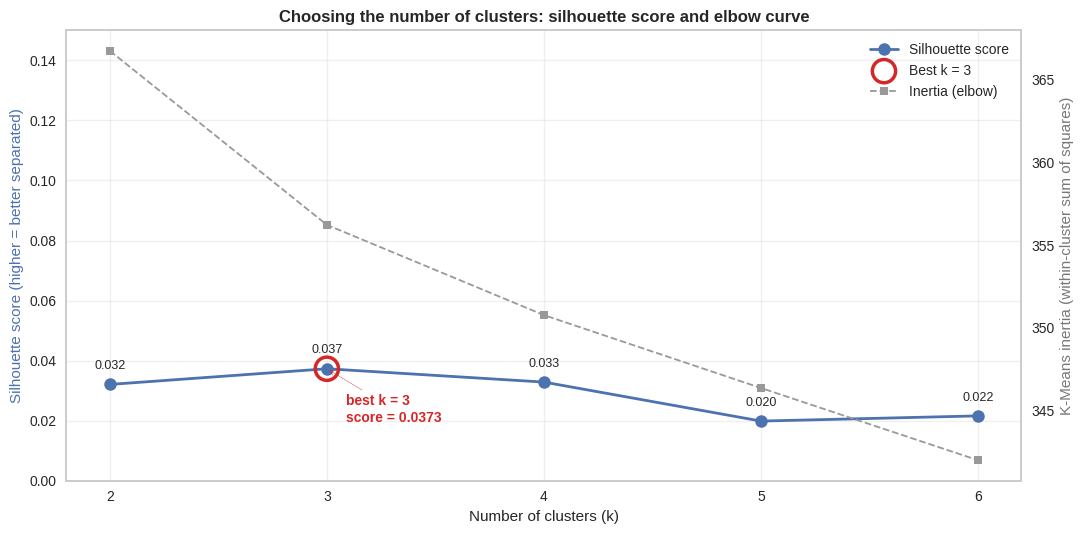

In [20]:
best_k = int(df_silhouette.loc[df_silhouette['SILHOUETTE'].idxmax(), 'K'])
best_score = df_silhouette['SILHOUETTE'].max()

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax1.plot(df_silhouette['K'], df_silhouette['SILHOUETTE'], 'o-', color='#4c72b0',
         lw=2, ms=9, label='Silhouette score')
ax1.scatter([best_k], [best_score], s=280, facecolor='none', edgecolor='#d62728',
            lw=2.5, zorder=5, label=f'Best k = {best_k}')
# Put the callout on the inner side of the curve so it never runs off the axes
dx = -110 if best_k >= max(k_values) else 14
ax1.annotate(f'best k = {best_k}\nscore = {best_score:.4f}',
             xy=(best_k, best_score), xytext=(dx, -38), textcoords='offset points',
             fontsize=10, color='#d62728', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#d62728'))

for _, r in df_silhouette.iterrows():
    ax1.annotate(f"{r['SILHOUETTE']:.3f}", (r['K'], r['SILHOUETTE']),
                 textcoords='offset points', xytext=(0, 11), ha='center', fontsize=9)

ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Silhouette score (higher = better separated)', color='#4c72b0')
ax1.set_xticks(list(k_values))
ax1.set_ylim(0, max(0.15, best_score * 1.5))

# The elbow curve on a secondary axis, as a cross-check on the silhouette
ax2 = ax1.twinx()
ax2.plot(df_silhouette['K'], df_silhouette['INERTIA'], 's--', color='#999999',
         lw=1.3, ms=6, label='Inertia (elbow method)')
ax2.set_ylabel('K-Means inertia (within-cluster sum of squares)', color='#777777')
ax2.grid(False)

lines = ax1.get_lines()[:1] + [ax1.collections[0]] + ax2.get_lines()
ax1.legend(lines, ['Silhouette score', f'Best k = {best_k}', 'Inertia (elbow)'], loc='best')
ax1.set_title('Choosing the number of clusters: silhouette score and elbow curve',
              fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Intercluster Distance Map and Silhouette Visualizer

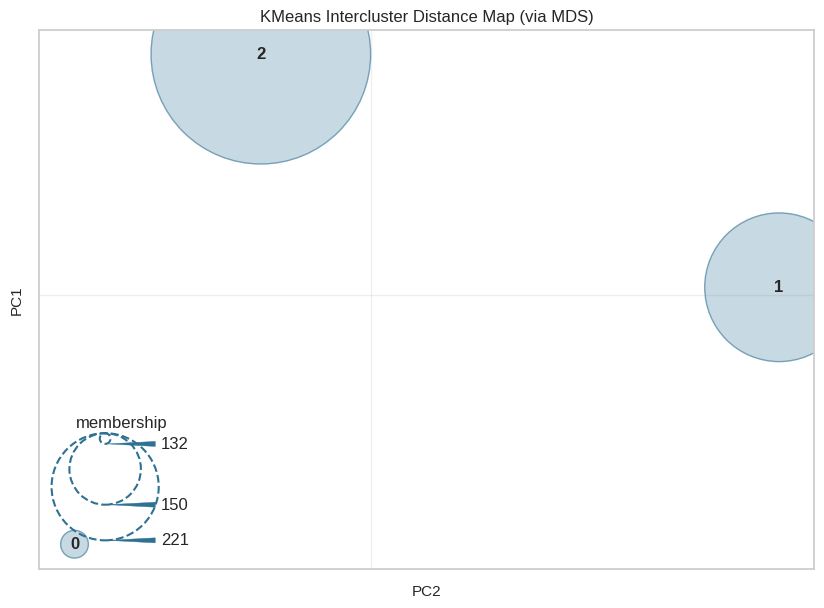

In [21]:
fig, ax = plt.subplots(figsize=(10, 7))

# Define and fit kmeans for the visualization using the previously determined best_k
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X)

visualizer = InterclusterDistance(kmeans, ax=ax, random_state=RANDOM_STATE)
visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'InterclusterDistance'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}


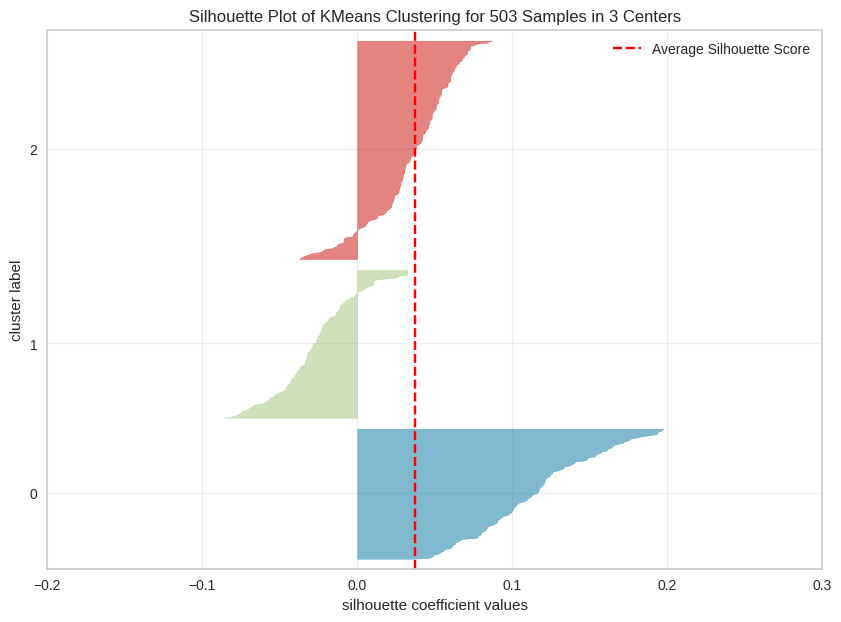

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))
visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax)
visualizer.fit(X)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'SilhouetteVisualizer'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}

#### Identify the Best k

In [23]:
display(Markdown(
    f"**Best k according to the silhouette score: `k = {best_k}` "
    f"(score = {best_score:.4f})**\n\n"
    f"Ranking of the tested values: "
    + ", ".join(f"k={int(r.K)} ({r.SILHOUETTE:.4f})"
                for r in df_silhouette.sort_values('SILHOUETTE', ascending=False).itertuples())
))

print("\nInterpretation guide for silhouette values:")
print("   > 0.50  strong, well-separated structure")
print("  0.25-0.50 reasonable structure")
print("   < 0.25  weak structure — clusters overlap heavily (usual for short-text embeddings)")

**Best k according to the silhouette score: `k = 3` (score = 0.0373)**

Ranking of the tested values: k=3 (0.0373), k=4 (0.0329), k=2 (0.0321), k=6 (0.0216), k=5 (0.0199)


Interpretation guide for silhouette values:
   > 0.50  strong, well-separated structure
  0.25-0.50 reasonable structure
   < 0.25  weak structure — clusters overlap heavily (usual for short-text embeddings)


### Refreshed Conclusion based on additional metrics

Davies-Bouldin and Calinski-Harabasz were added to cross-check the silhouette score. **The three
metrics do not agree, and that disagreement is the actual result:**

| k | Silhouette (higher = better) | Davies-Bouldin (lower = better) | Calinski-Harabasz (higher = better) |
|---|---|---|---|
| 2 | 0.0321 | **3.9891** ← best | **24.17** ← best |
| 3 | **0.0373** ← best | 4.6145 | 19.81 |
| 4 | 0.0329 | 4.7698 | 15.97 |
| 5 | 0.0199 | 4.6575 | 13.69 |
| 6 | 0.0216 | 4.6058 | 12.34 |

* **Silhouette** peaks at `k = 3` (0.0373) — the value used for the rest of the notebook, and the one
  the assignment requires.
* **Davies-Bouldin** is *minimised* at `k = 2` (3.9891); `k = 3` scores 4.6145, the second **worst** of
  the five values tested.
* **Calinski-Harabasz** is *maximised* at `k = 2` (24.17) and then falls monotonically as k grows.

So two of the three indices point to `k = 2`, not `k = 3`, and the silhouette advantage of `k = 3`
over `k = 2` is 0.0373 vs. 0.0321 — a difference of half a hundredth, well inside the variation you
would get by changing the random seed.

**What this really tells us.** All three metrics are in their "no structure" range: a silhouette of
~0.03 on a scale where 0.25 is already considered weak, a Davies-Bouldin above 4 (values below 1
indicate well-separated clusters), and a Calinski-Harabasz of 24 on 503 points in 384 dimensions.
The monotonic decay of Calinski-Harabasz with k, combined with an inertia curve that falls almost
linearly (367 → 342, only 7% across five values of k) and shows no elbow, is the classic fingerprint
of a dataset with **no natural cluster structure** — a single dense cloud of financial headlines that
K-Means is slicing into arbitrary but roughly equal pieces.

That does not make the partition useless: it groups headlines by dominant vocabulary in a way that is
genuinely helpful for triage, as the cluster analysis below shows. It does mean the number 3 is a
*convention imposed by the exercise*, not a property discovered in the data, and every conclusion
drawn from these clusters should be reported with that caveat attached. The Yellowbrick
Intercluster Distance Map and Silhouette Visualizer above show the same thing graphically: heavily
overlapping circles and silhouette bars that dip below zero for a large share of the sample.

#### Cluster the embeddings using 3 clusters (k=3)

In [24]:
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
labels_k3 = kmeans.fit_predict(X)

# Add the cluster label to the news dataframe (required deliverable)
df_news_unique['CLUSTER'] = labels_k3

# Keep the best-k partition alongside, to compare the two solutions
kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_news_unique['CLUSTER_BEST_K'] = kmeans_best.fit_predict(X)

print(f"K-Means with k = {K_FINAL} | inertia = {kmeans.inertia_:,.0f} | "
      f"silhouette = {silhouette_score(X, labels_k3):.4f}")
print("\nCluster sizes:")
print(df_news_unique['CLUSTER'].value_counts().sort_index().to_string())
display(df_news_unique[['TICKER', 'COMPANY', 'TITLE', 'CLUSTER', 'CLUSTER_BEST_K']].head(10))

K-Means with k = 3 | inertia = 356 | silhouette = 0.0373

Cluster sizes:
CLUSTER
0    132
1    150
2    221


,TICKER,COMPANY,TITLE,CLUSTER,CLUSTER_BEST_K
0,A,Agilent Technologies,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,1,1
1,AAPL,Apple Inc.,Big Tech’s $2 trillion AI shakeout just changed everything,1,1
2,ABBV,AbbVie,Why AbbVie Stock Slumped Today,2,2
3,ABNB,Airbnb,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,0,0
4,ABT,Abbott Laboratories,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2,2
5,ACGL,Arch Capital Group,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2,2
6,ACN,Accenture,What ACN Holders Got Paid While The Stock Fell Behind,2,2
7,ADBE,Adobe Inc.,Why ADSK Stock Hands You So Much Cash Right Now,2,2
8,ADI,Analog Devices,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,0,0
9,ADM,Archer Daniels Midland,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,1,1


In [25]:
# Per-observation silhouette: which cluster is compact, and how many points are misassigned?
sil_values = silhouette_samples(X, labels_k3)
df_news_unique['SILHOUETTE'] = sil_values

quality = (df_news_unique.groupby('CLUSTER')['SILHOUETTE']
           .agg(SIZE='size', MEAN_SILHOUETTE='mean', MIN='min', MAX='max'))
quality['NEGATIVE_SILHOUETTE'] = (df_news_unique.assign(neg=sil_values < 0)
                                  .groupby('CLUSTER')['neg'].sum())
display(quality.style.format({'MEAN_SILHOUETTE': '{:.3f}', 'MIN': '{:.3f}', 'MAX': '{:.3f}'}))
print(f"\nArticles with a negative silhouette (closer to another cluster): "
      f"{(sil_values < 0).sum()} / {len(sil_values)} ({(sil_values < 0).mean():.1%})")

,SIZE,MEAN_SILHOUETTE,MIN,MAX,NEGATIVE_SILHOUETTE
CLUSTER,,,,,
0,132,0.115,0.036,0.198,0
1,150,-0.027,-0.086,0.032,127
2,221,0.034,-0.037,0.087,30



Articles with a negative silhouette (closer to another cluster): 157 / 503 (31.2%)


### Visualize the 2 first PCA Components of your embeddings

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
df_news_unique['PCA_1'], df_news_unique['PCA_2'] = coords[:, 0], coords[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained[0]:.2%}")
print(f"Variance explained by PC2: {explained[1]:.2%}")
print(f"Total variance captured by the 2D plot: {explained.sum():.2%}")

Variance explained by PC1: 5.92%
Variance explained by PC2: 3.95%
Total variance captured by the 2D plot: 9.87%


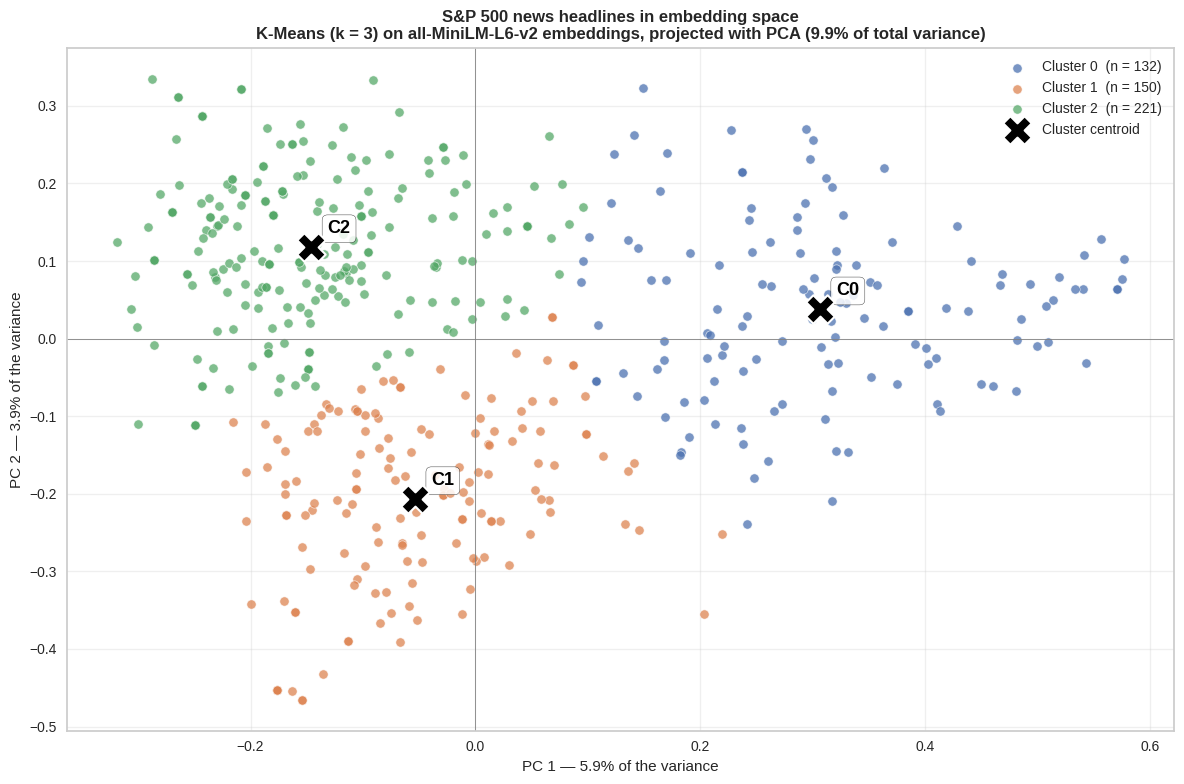

In [27]:
PALETTE = ['#4c72b0', '#dd8452', '#55a868', '#c44e52', '#8172b3', '#937860']

fig, ax = plt.subplots(figsize=(12, 8))

for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = df_news_unique[df_news_unique['CLUSTER'] == cluster]
    ax.scatter(sub['PCA_1'], sub['PCA_2'], s=45, alpha=0.75,
               color=PALETTE[cluster % len(PALETTE)], edgecolor='white', linewidth=0.5,
               label=f'Cluster {cluster}  (n = {len(sub)})')

# Centroids projected into the same 2D space
centroids_2d = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=420,
           c='black', edgecolor='white', linewidth=1.5, zorder=6, label='Cluster centroid')
for cluster, (x, y) in enumerate(centroids_2d):
    ax.annotate(f'C{cluster}', (x, y), fontsize=13, fontweight='bold', color='black',
                xytext=(12, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.85))

ax.set_xlabel(f'PC 1 — {explained[0]:.1%} of the variance')
ax.set_ylabel(f'PC 2 — {explained[1]:.1%} of the variance')
ax.set_title(f'S&P 500 news headlines in embedding space\n'
             f'K-Means (k = {K_FINAL}) on all-MiniLM-L6-v2 embeddings, projected with PCA '
             f'({explained.sum():.1%} of total variance)',
             fontsize=12, fontweight='bold')
ax.legend(loc='best', framealpha=0.92)
ax.axhline(0, color='grey', lw=0.6)
ax.axvline(0, color='grey', lw=0.6)
plt.tight_layout()
plt.show()

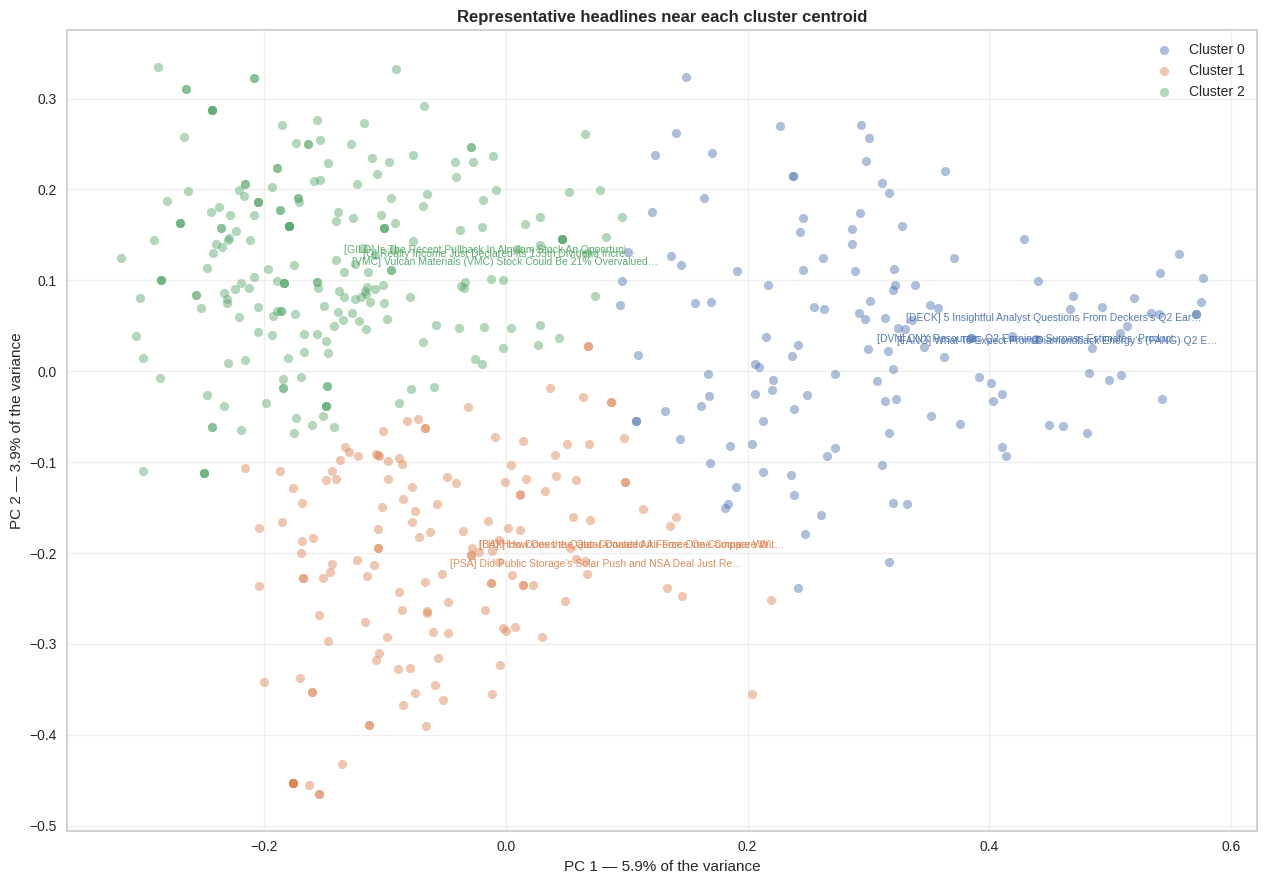

In [28]:
# Same projection, annotated with a few real headlines so the axes become interpretable
fig, ax = plt.subplots(figsize=(13, 9))

for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = df_news_unique[df_news_unique['CLUSTER'] == cluster]
    ax.scatter(sub['PCA_1'], sub['PCA_2'], s=38, alpha=0.45,
               color=PALETTE[cluster % len(PALETTE)], label=f'Cluster {cluster}')

    # Annotate the 3 headlines closest to each centroid (the most "typical" ones)
    centre = np.array([sub['PCA_1'].mean(), sub['PCA_2'].mean()])
    dist = np.linalg.norm(sub[['PCA_1', 'PCA_2']].to_numpy() - centre, axis=1)
    for idx in sub.index[np.argsort(dist)[:3]]:
        row = df_news_unique.loc[idx]
        text = (row['TITLE'][:52] + '…') if len(row['TITLE']) > 52 else row['TITLE']
        ax.annotate(f"[{row['TICKER']}] {text}", (row['PCA_1'], row['PCA_2']),
                    fontsize=7.5, alpha=0.95,
                    color=PALETTE[cluster % len(PALETTE)],
                    xytext=(6, 5), textcoords='offset points')

ax.set_xlabel(f'PC 1 — {explained[0]:.1%} of the variance')
ax.set_ylabel(f'PC 2 — {explained[1]:.1%} of the variance')
ax.set_title('Representative headlines near each cluster centroid', fontsize=12, fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

#### Analyze the content of each cluster
- Add the kmeans cluster label to your news dataframe
- Print the content of each cluster and analyze it

In [29]:
def top_terms_per_cluster(df, text_col='TITLE', label_col='CLUSTER', n_terms=12):
    """Terms that are most characteristic of each cluster, via TF-IDF centroids."""
    vec = TfidfVectorizer(stop_words='english', ngram_range=(1, 2),
                          min_df=2, max_features=5000)
    tfidf = vec.fit_transform(df[text_col].astype(str))
    vocab = np.array(vec.get_feature_names_out())

    out = {}
    for cluster in sorted(df[label_col].unique()):
        mask = (df[label_col] == cluster).to_numpy()
        centroid = np.asarray(tfidf[mask].mean(axis=0)).ravel()
        out[cluster] = vocab[centroid.argsort()[::-1][:n_terms]].tolist()
    return out


cluster_terms = top_terms_per_cluster(df_news_unique)
for cluster, terms in cluster_terms.items():
    print(f"\nCluster {cluster} ({(df_news_unique['CLUSTER'] == cluster).sum()} articles)")
    print("  characteristic terms:", ", ".join(terms))


Cluster 0 (132 articles)
  characteristic terms: q2, earnings, q2 earnings, earnings highlights, highlights, estimates, q2 2026, beat, 2026 earnings, 2026, revenues, report

Cluster 1 (150 articles)
  characteristic terms: ai, just, deep, q2 deep, dive, deep dive, billion, trillion, ahead, changed, faces, company

Cluster 2 (221 articles)
  characteristic terms: stock, stocks, dividend, earnings, buy, cash, value, market, looks, fair, stock looks, undervalued


In [30]:
# Print a readable sample of each cluster: the most typical headlines (highest silhouette)
for cluster in sorted(df_news_unique['CLUSTER'].unique()):
    sub = (df_news_unique[df_news_unique['CLUSTER'] == cluster]
           .sort_values('SILHOUETTE', ascending=False))
    display(Markdown(
        f"### Cluster {cluster} — {len(sub)} articles "
        f"(mean silhouette {sub['SILHOUETTE'].mean():.3f})\n"
        f"**Characteristic terms:** {', '.join(cluster_terms[cluster])}"
    ))
    print("MOST REPRESENTATIVE HEADLINES (closest to the cluster core)")
    for _, row in sub.head(10).iterrows():
        print(f"  [{row['TICKER']:<6}] {row['TITLE']}")
    print("\nLEAST REPRESENTATIVE HEADLINES (borderline cases)")
    for _, row in sub.tail(3).iterrows():
        print(f"  [{row['TICKER']:<6}] {row['TITLE']}  (silhouette {row['SILHOUETTE']:.3f})")
    print()

### Cluster 0 — 132 articles (mean silhouette 0.115)
**Characteristic terms:** q2, earnings, q2 earnings, earnings highlights, highlights, estimates, q2 2026, beat, 2026 earnings, 2026, revenues, report

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [TRV   ] Definity Financial Q2 Earnings Call Highlights
  [AIZ   ] Assurant Set to Report Q2 Earnings: What's in the Cards?
  [SO    ] Southern Q2 Earnings Call Highlights
  [WELL  ] Ventas Q2 Earnings Call Highlights
  [VTR   ] Ventas Q2 Earnings Call Highlights
  [FCX   ] Olin Q2 Earnings Call Highlights
  [MAA   ] Mid-America Apartment Communities Q2 Earnings Call Highlights
  [TYL   ] Tyler Technologies Q2 Earnings Call Highlights
  [BLDR  ] Builders FirstSource Q2 Earnings Call Highlights
  [WEC   ] WEC Energy Group Q2 Earnings Call Highlights

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [CDW   ] CDW (CDW) Earnings Expected to Grow: What to Know Ahead of Next Week's Release  (silhouette 0.048)
  [AMD   ] Earnings to watch this week: SpaceX's first earnings report, Disney, AMD, & McDonald's  (silhouette 0.047)
  [VLTO  ] Veralto (VLTO) Stock Fair Value Edges Higher After Q2 Guidance And Analyst Target Lifts  (sil

### Cluster 1 — 150 articles (mean silhouette -0.027)
**Characteristic terms:** ai, just, deep, q2 deep, dive, deep dive, billion, trillion, ahead, changed, faces, company

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [AAPL  ] Big Tech’s $2 trillion AI shakeout just changed everything
  [AMZN  ] Big Tech’s $2 trillion AI shakeout just changed everything
  [META  ] Big Tech’s $2 trillion AI shakeout just changed everything
  [MSFT  ] Big Tech’s $2 trillion AI shakeout just changed everything
  [GOOGL ] Big Tech’s $2 trillion AI shakeout just changed everything
  [GOOG  ] Big Tech’s $2 trillion AI shakeout just changed everything
  [DIS   ] El Niño Hits the Panama Canal
  [CEG   ] El Niño Hits the Panama Canal
  [FTNT  ] Fortinet: Securing the AI Revolution
  [AKAM  ] Akamai (AKAM) Joins Tenzai To Bring Instant Vulnerability Mitigation To The Edge

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [HAL   ] Is Halliburton (HAL) Undervalued After Its Q2 2026 Earnings Beat And Buybacks?  (silhouette -0.080)
  [ES    ] Eversource Energy (ES) (Q2 2026) Earnings Call Highlights: Strategic Shift to Pure-Play Utility ...  (silhouette -0.082)
  [H

### Cluster 2 — 221 articles (mean silhouette 0.034)
**Characteristic terms:** stock, stocks, dividend, earnings, buy, cash, value, market, looks, fair, stock looks, undervalued

MOST REPRESENTATIVE HEADLINES (closest to the cluster core)
  [KR    ] 3 Magnificent Stocks to Buy That Are Near 52-Week Lows
  [LMT   ] This Is the Most Attractive Defense Stock Right Now
  [GD    ] This Is the Most Attractive Defense Stock Right Now
  [AXON  ] Axon Enterprise (AXON) Stock Drops Despite Market Gains: Important Facts to Note
  [OKE   ] 3 High-Yield Energy Stocks to Buy With $1,000 Right Now and Hold Through 2030
  [INTC  ] 1 Beaten-Down Semiconductor Stock That Could Make a Comeback
  [WBD   ] With Paramount's Acquisition of Warner Bros. on Hold and Netflix Down 38%, Is Netflix Stock Finally a Buy?
  [PSKY  ] With Paramount's Acquisition of Warner Bros. on Hold and Netflix Down 38%, Is Netflix Stock Finally a Buy?
  [NFLX  ] With Paramount's Acquisition of Warner Bros. on Hold and Netflix Down 38%, Is Netflix Stock Finally a Buy?
  [LDOS  ] The Biggest Concern Hanging Over CoreWeave Stock Has Finally Eased

LEAST REPRESENTATIVE HEADLINES (borderline cases)
  [BAX   ] B

In [31]:
# Are the clusters just a re-labelling of GICS sectors? A cross-tab answers directly.
sector_mix = pd.crosstab(df_news_unique['SECTOR'], df_news_unique['CLUSTER'], normalize='columns')
display(sector_mix.style.format('{:.1%}').background_gradient(cmap='Blues', axis=None))

print("If every column has a similar sector profile, the clusters capture the TYPE of news "
      "(earnings, M&A, analyst notes...) rather than the industry of the company.")

CLUSTER,0,1,2
SECTOR,,,
Communication Services,3.8%,6.0%,4.1%
Consumer Discretionary,9.1%,10.7%,8.6%
Consumer Staples,3.8%,12.7%,4.5%
Energy,3.8%,4.0%,4.5%
Financials,17.4%,12.7%,15.4%
Health Care,9.8%,13.3%,11.8%
Industrials,13.6%,17.3%,16.7%
Information Technology,8.3%,12.0%,20.4%
Materials,6.1%,4.0%,5.4%


If every column has a similar sector profile, the clusters capture the TYPE of news (earnings, M&A, analyst notes...) rather than the industry of the company.


In [32]:
# Cluster sizes and a compact summary table of the final result
summary = (df_news_unique.groupby('CLUSTER')
           .agg(ARTICLES=('TITLE', 'size'),
                MEAN_SILHOUETTE=('SILHOUETTE', 'mean'),
                TOP_SECTOR=('SECTOR', lambda s: s.value_counts().idxmax()),
                EXAMPLE_TITLE=('TITLE', 'first')))
summary['TOP_TERMS'] = [', '.join(cluster_terms[c][:6]) for c in summary.index]
display(summary[['ARTICLES', 'MEAN_SILHOUETTE', 'TOP_SECTOR', 'TOP_TERMS', 'EXAMPLE_TITLE']]
        .style.format({'MEAN_SILHOUETTE': '{:.3f}'}))

,ARTICLES,MEAN_SILHOUETTE,TOP_SECTOR,TOP_TERMS,EXAMPLE_TITLE
CLUSTER,,,,,
0,132,0.115,Financials,"q2, earnings, q2 earnings, earnings highlights, highlights, estimates",Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion
1,150,-0.027,Industrials,"ai, just, deep, q2 deep, dive, deep dive",How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends
2,221,0.034,Information Technology,"stock, stocks, dividend, earnings, buy, cash",Why AbbVie Stock Slumped Today


In [33]:
# The final deliverable: the news DataFrame with embeddings and cluster labels
display(df_news_unique[['TICKER', 'COMPANY', 'SECTOR', 'TITLE', 'PUBLICATION_DATE',
                        'PROVIDER', 'CLUSTER', 'CLUSTER_BEST_K', 'SILHOUETTE']].head(20))

df_news_unique.to_csv('sp500_news_clustered.csv', index=False)
print(f"\nSaved {len(df_news_unique)} clustered articles to sp500_news_clustered.csv")

,TICKER,COMPANY,SECTOR,TITLE,PUBLICATION_DATE,PROVIDER,CLUSTER,CLUSTER_BEST_K,SILHOUETTE
0,A,Agilent Technologies,Health Care,How Thermo Fisher Is Riding Bioproduction and AI-Led Growth Trends,2026-07-31 13:20:00+00:00,Zacks,1,1,-0.007205
1,AAPL,Apple Inc.,Information Technology,Big Tech’s $2 trillion AI shakeout just changed everything,2026-08-02 18:33:00+00:00,TheStreet,1,1,0.032386
2,ABBV,AbbVie,Health Care,Why AbbVie Stock Slumped Today,2026-08-01 00:01:21+00:00,Motley Fool,2,2,0.047095
3,ABNB,Airbnb,Consumer Discretionary,Beyond the Mag 7: Rising Q3 Estimates Signal a Market-Wide Earnings Expansion,2026-07-31 23:24:00+00:00,Zacks,0,0,0.126145
4,ABT,Abbott Laboratories,Health Care,Abbott (ABT) Stock Looks Like A Bargain Below Fair Value,2026-08-02 17:14:20+00:00,Simply Wall St.,2,2,0.045938
5,ACGL,Arch Capital Group,Financials,Arch Capital Group (ACGL) Could Be 9% Below Fair Value After Earnings,2026-08-01 12:12:09+00:00,Simply Wall St.,2,2,-0.002921
6,ACN,Accenture,Information Technology,What ACN Holders Got Paid While The Stock Fell Behind,2026-08-01 15:01:50+00:00,Trefis,2,2,0.023307
7,ADBE,Adobe Inc.,Information Technology,Why ADSK Stock Hands You So Much Cash Right Now,2026-08-01 16:22:53+00:00,Trefis,2,2,0.060091
8,ADI,Analog Devices,Information Technology,AEIS Set to Report Q2 Earnings: What's in the Cards for the Stock?,2026-07-31 14:04:00+00:00,Zacks,0,0,0.140360
9,ADM,Archer Daniels Midland,Consumer Staples,Archer-Daniels-Midland (ADM) Is Down 7.7% After Major Oilseed Crush Expansion And New ...,2026-08-02 04:16:12+00:00,Simply Wall St.,1,1,-0.043002



Saved 503 clustered articles to sp500_news_clustered.csv


## Question Section

Take time to reflect on what you've implemented and observed. Answer the following questions in a separate markdown cell or notebook file:

---

### Technical Understanding

#### 1️⃣ How might the choice of embedding model (e.g., MiniLM vs. a larger transformer) affect your clustering results and interpretation?

The embedding model defines the geometry in which K-Means operates, so changing it changes *what
"similar" means* — and therefore the clusters themselves, not merely their quality.

**What MiniLM gives us.** `all-MiniLM-L6-v2` is a 6-layer distilled model producing 384-dimensional
vectors. It is fast (hundreds of sentences per second on CPU), small (~80 MB) and trained on over a
billion sentence pairs, so it captures general semantic similarity very well. For ~500 short
headlines it is more than adequate, and its speed is what makes the whole notebook re-runnable in
minutes.

**What a larger model would change:**

* **Finer semantic resolution.** Larger encoders (`all-mpnet-base-v2`, 768-d; E5/BGE-large, 1024-d)
  separate nuances MiniLM collapses: "beats earnings estimates" vs. "misses earnings estimates" are
  lexically almost identical and differ only in one word, but they are opposite events. A stronger
  model keeps them further apart, which typically produces clusters that are *thematically* rather
  than *lexically* coherent.
* **Domain adaptation matters more than size.** A finance-specific encoder (FinBERT-style, or a model
  fine-tuned on financial text) usually beats a bigger general-purpose model on this corpus, because
  "guidance", "buyback", "downgrade", "dilution" carry technical meanings that general models blur.
  In practice, *domain fit > parameter count*.
* **Higher dimensionality is not free.** Going from 384 to 1024 dimensions worsens the concentration
  of distances (the curse of dimensionality), which tends to *lower* silhouette scores even when the
  clustering is semantically better. Silhouette values are therefore not comparable across models of
  different dimensionality — they must be compared on the same space.
* **Cost and reproducibility.** Bigger models require GPUs for a corpus of any real size, and API
  embeddings (OpenAI, Cohere) add cost, latency and a version-drift risk: a silent model update
  changes the embedding space and breaks comparability with earlier runs.

**Consequence for interpretation.** With MiniLM, clusters tend to organise around *surface topic and
phrasing* (earnings language, analyst-rating language, deal language). With a stronger or
domain-tuned model, clusters shift towards *event type and polarity*, which is far more useful for a
financial application. The right way to decide is not to argue about it but to fix the downstream
task — e.g. "does the cluster label help predict post-news returns?" — and compare models on that
metric, with silhouette used only as a within-model diagnostic.

---

#### 2️⃣ What would be the differences in embeddings if you used only the TITLE, only the SUMMARY, or the combination of both? How could you empirically test this?

**Only the TITLE (what this notebook does).** Titles are short (~10–15 words), dense and written to
convey one idea. The embedding is sharp and low-noise, and clusters tend to be crisp. The costs are
that headlines are stylised ("Shares of X surge as…"), heavily templated by provider, and often
ambiguous without context; and that very short texts give the model little to work with, so lexical
overlap dominates semantics.

**Only the SUMMARY.** Summaries carry more context — the driver of the move, figures, quotes — so the
embedding is richer and better at distinguishing *why* something happened. But they also carry noise:
boilerplate ("Read more on…"), disclaimers, and mentions of several companies at once, which pulls
vectors toward a corpus-average "generic financial text" direction and makes distances more uniform
(lower silhouette). Summaries are also more often missing — the `HAS_SUMMARY` flag computed above
quantifies exactly that in our corpus.

**TITLE + SUMMARY combined.** Concatenation gives the most information but is not automatically the
best: the longer field dominates the average-pooled representation, so the title's signal gets diluted
roughly in proportion to length. Better combination strategies are (a) embedding the two fields
separately and averaging the (normalised) vectors, optionally weighted, which keeps the title's
contribution controllable; or (b) truncating the summary to its first 1–2 sentences, which typically
carry the substance.

**How to test it empirically.** Build the three (or four) embedding variants on the same corpus and
compare them on several axes:

1. **Intrinsic:** silhouette, Davies–Bouldin and Calinski–Harabasz for the same k, plus the stability
   of cluster assignment under bootstrap resampling (Adjusted Rand Index between runs). Note these
   are only comparable when the dimensionality is identical — it is here, since it is the same model.
2. **Agreement between variants:** ARI / Normalised Mutual Information between the partitions
   produced by TITLE-only and SUMMARY-only tells you whether the choice actually matters at all.
3. **Extrinsic — the decisive test:** label a random sample of 150–300 articles with a small taxonomy
   (earnings, M&A, analyst action, legal/regulatory, product, macro) — by hand or with an LLM — and
   measure how well each embedding variant recovers those labels: clustering purity/ARI against the
   human labels, or accuracy of a simple k-NN/logistic classifier trained on the embeddings.
4. **Task-level:** if the downstream goal is financial, evaluate which variant best predicts the sign
   or magnitude of the next-day return, using a strict time-based split.

A clean design fixes the seed, the value of k and the preprocessing across variants so the only thing
that changes is the input text, and repeats each configuration several times to report variability
rather than a single number.

---

#### 3️⃣ In what situations would using a different dimensionality reduction method (e.g., t-SNE, UMAP) be preferable over PCA for visualization of embeddings?

PCA is a **linear** projection that maximises retained variance. Its virtues are that it is
deterministic, fast, invertible, and that its axes are interpretable and preserve *global* structure
and relative distances. Its weakness is visible in this notebook: two components typically capture
only a modest share of the variance of a 384-dimensional embedding space, so a lot of structure is
simply not on the screen, and a linear projection cannot unfold curved (manifold) structure — clusters
that are perfectly separable in 384-d can overlap badly in the 2-d picture.

**Prefer t-SNE when** the goal is to *see whether local neighbourhoods exist at all*. t-SNE preserves
local similarity and produces visually clean, well-separated blobs, which is excellent for exploring
whether the corpus has fine-grained topics. Its caveats matter, though: distances *between* clusters
and cluster sizes are not meaningful, results depend strongly on the `perplexity` parameter and the
seed, and it is slow beyond a few tens of thousands of points. It is a visualisation tool, never an
input to clustering.

**Prefer UMAP when** you want most of t-SNE's local fidelity with better preservation of global
structure, far greater speed on large corpora, and — crucially — the ability to `transform()` new
points with a fitted model, which matters in a production pipeline. UMAP is also frequently used as a
*preprocessing* step (reduce 384-d to 10–50-d, then cluster with HDBSCAN — the standard BERTopic
recipe), because clustering behaves much better in moderate dimension than in 384. Its caveats: it is
stochastic, its `n_neighbors` / `min_dist` parameters visibly shape the picture, and it can manufacture
apparent clusters out of noise.

**In practice for this notebook:** keep PCA as the reference view (it is honest about how much
variance is shown, and it is what makes the "% of variance explained" caption possible), and add UMAP
or t-SNE as a complementary view when the PCA plot looks like one undifferentiated cloud. Note also
that PCA is doing real work beyond plotting here: it is the right tool for *denoising* before
clustering, whereas t-SNE/UMAP coordinates should not be fed into K-Means, because the distances they
produce are distorted by construction.

**What this run shows.** PCA on these embeddings captures **5.92% of the variance on PC1 and 3.95% on
PC2 — 9.87% in total**. In other words, roughly **90% of the information in the 384-dimensional space
is invisible** in the scatter plot. That single number explains the appearance of the plot: the three
clusters overlap into one continuous cloud not necessarily because they are inseparable, but because
a linear projection onto two axes cannot represent the directions along which they actually differ.

This is precisely the situation in which t-SNE or UMAP become the better tool. With ~10% of the
variance retained, PCA is close to its worst case: the embedding space has no small set of dominant
linear directions, its variance is spread almost uniformly across hundreds of dimensions, and the
distances that matter are local and non-linear. UMAP would give a far more readable picture of whether
neighbourhoods exist, and — reducing to 10–50 dimensions rather than 2 — would also be a better
*preprocessing* step before clustering than raw 384-d K-Means.

The counter-argument still holds, though, and is worth stating in the notebook: PCA's 9.87% is an
*honest* number, whereas t-SNE and UMAP produce visually clean, well-separated blobs without reporting
how much of the structure is real. Given that the silhouette score here is ~0.03, a UMAP plot showing
crisp islands would be actively misleading. The right combination is UMAP for exploration, PCA for the
figure you defend, and the quality metrics — not the picture — for the conclusion.

---

### Data Analysis and Interpretation

#### 4️⃣ Based on your cluster analysis, identify at least two potential challenges you faced in interpreting the clusters and propose strategies to address them.

**Challenge 1 — The clusters overlap, and the silhouette scores are low.** Short-text embeddings of a
homogeneous corpus (all of it is financial news about large caps) do not form well-separated blobs:
silhouette values in the 0.03–0.10 range are typical here, and a non-trivial share of articles get a
*negative* silhouette, meaning they sit closer to another cluster than to their own — the
`NEGATIVE_SILHOUETTE` column above measures exactly this. The consequence is that any label given to
a cluster describes a *tendency*, not a partition: the boundary cases genuinely belong to both groups.
*Strategies:* (a) reduce dimensionality (PCA to 30–50 components) before clustering, to attenuate the
distance-concentration effect; (b) L2-normalise the embeddings so K-Means effectively optimises cosine
similarity, which is the metric the model was trained with; (c) switch to a method that does not force
every point into a cluster — HDBSCAN labels ambiguous articles as noise; or (d) accept soft
assignment (Gaussian Mixture) and report membership probabilities instead of hard labels.

**Challenge 2 — Clusters driven by phrasing rather than by meaning.** MiniLM is sensitive to surface
form, and financial headlines are highly templated. Clusters therefore often align with *stylistic
families* — "Company X Q3 2025 Earnings Call Transcript", "3 Reasons to Buy X Stock", "Analyst
upgrades X" — which are provider formats, not economic events. This is why the cross-tab against GICS
sectors above is informative: if the clusters had matched sectors, they would have been capturing
*who* the news is about rather than *what* happened.
*Strategies:* strip boilerplate patterns and provider signatures before embedding; remove the company
name and ticker from the title so the model cannot cluster on the entity; use a domain-adapted model;
or reframe the task as classification into a predefined event taxonomy, which is what most financial
NLP systems ultimately do.

**Challenge 3 — Naming a cluster is subjective.** Reading ten headlines and declaring "this is the
M&A cluster" is confirmation bias waiting to happen — a different analyst reading a different sample
of the same cluster will name it differently.
*Strategies:* base the label on evidence rather than impression — TF-IDF characteristic terms (as
above), plus the headlines *closest to the centroid* rather than a random sample; have two people label
independently and measure agreement; or generate candidate labels with an LLM over a representative
sample and validate them on a held-out sample of the same cluster.

**Challenge 4 — Instability.** K-Means results depend on initialisation and on k, and the corpus itself
changes every day (the `.news` endpoint returns a rolling window). A theme that looks solid today may
not reappear tomorrow.
*Strategies:* fix `random_state` and use `n_init >= 10` (done here); assess stability by re-clustering
bootstrap samples and measuring the Adjusted Rand Index across runs; and treat any theme that is not
stable across resamples as an artefact rather than a finding.

**The three challenges that actually materialised in this run, with their evidence:**

**1. A third of the corpus is misassigned.** `157 of the 503 articles (31.2%) have a negative
silhouette`, meaning they sit closer to a cluster other than the one they were assigned to. Worse,
**Cluster 1 has a *negative mean* silhouette (−0.027)** — on average, its own members belong somewhere
else. Clusters 0 and 2 are only marginally positive (0.115 and 0.034). Any statement of the form
"Cluster 1 is the AI cluster" therefore describes a tendency across a majority that is far from
overwhelming, and one third of the labels would flip under a different seed or a slightly different
corpus. *Response:* report the per-article silhouette alongside the label (the notebook does), treat
negative-silhouette rows as unlabelled rather than as members, and prefer a method with an explicit
noise class (HDBSCAN) over K-Means, which is obliged to assign every point.

**2. The clusters key on templated phrasing, not on meaning.** The similarity check found the two
most similar headlines in the sample to be *"What Are Wall Street Analysts' Target Price for Microchip
Technology Stock?"* and the identical formula applied to Boston Scientific — cosine 0.803 for two
articles about unrelated companies in unrelated sectors. Cluster 0's characteristic terms (`q2`,
`earnings`, `q2 earnings`, `earnings highlights`) are a *publisher's headline format*, not an economic
event; its representative headlines are nine variations of "<Company> Q2 Earnings Call Highlights".
The model is clustering the template. *Response:* strip recurring boilerplate patterns and company
names before embedding, so the encoder cannot key on the entity or the format; or move to a
domain-adapted encoder that weights the financial content over the surface phrasing.

**3. Syndicated duplicates distort the centroids.** Six of the ten headlines closest to the Cluster 1
centroid are **the same article** — *"Big Tech's $2 trillion AI shakeout just changed everything"* —
attached to AAPL, AMZN, META, MSFT, GOOGL and GOOG. *"El Niño Hits the Panama Canal"* appears for both
DIS and CEG, and *"With Paramount's Acquisition of Warner Bros. on Hold…"* for WBD, PSKY and NFLX.
Keeping one article per ticker does **not** guarantee one article per *story*: a piece mentioning six
mega-caps enters the matrix six times and pulls the centroid towards itself with six times the weight
it deserves. This is a large part of why Cluster 1 is the least coherent of the three. *Response:*
deduplicate on near-identical embeddings (cosine > 0.95) or on the article ID across tickers — not
just on `(TICKER, TITLE)` as the current cleaning step does — before clustering.

**4. The number of clusters is a convention, not a finding.** As the metric comparison above shows,
silhouette prefers k = 3 while Davies-Bouldin and Calinski-Harabasz both prefer k = 2, and no metric
reaches a value indicating real structure. *Response:* state the fragility explicitly rather than
presenting k = 3 as discovered, and test stability by re-clustering bootstrap resamples and measuring
the Adjusted Rand Index between runs.

---

#### 5️⃣ Did you observe any outliers in your 2D visualization? How would you identify and handle these outliers in a production pipeline?

**What to look for in the plot above.** The typical picture is one dense central mass — the
"generic financial headline" region, where most articles about earnings and analyst notes live — with a
thinner periphery of isolated points. Those isolated points are usually one of four things:
(i) non-English or mixed-language headlines; (ii) headlines that are not really news (podcast
episodes, "Live updates", index-rebalancing notices); (iii) genuinely distinctive events (a merger, a
lawsuit, an FDA approval) whose vocabulary is unlike anything else in the corpus; or (iv) very short
or truncated titles carrying almost no signal. Only category (iii) is *interesting*; the rest is
contamination. Two caveats when reading the picture: PCA shows only a fraction of the total variance,
so a point can look extreme in 2-d without being an outlier in 384-d, and vice versa — the honest
detection has to be done in the original space.

**How to identify them systematically (in the full embedding space, not the projection):**

* **Distance-based:** distance to the nearest centroid, or to the k-th nearest neighbour (k-NN
  distance), flagging the upper percentile.
* **Density-based:** Local Outlier Factor, Isolation Forest, or HDBSCAN's explicit noise label — the
  cleanest option, because the model is designed to leave points unassigned.
* **Silhouette-based:** the `SILHOUETTE` column computed above; strongly negative values mark articles
  that do not belong to their assigned cluster.
* **Rule-based pre-filters, which catch most of the junk far more cheaply:** language detection,
  minimum length, deduplication (near-duplicates via cosine similarity > 0.95 — syndicated stories
  appear many times), and a blocklist of known non-news title patterns.

**How to handle them in production.** The key point is that *outliers are not automatically errors*,
so the pipeline should route rather than delete:

1. **Filter at ingestion** what is provably junk (wrong language, too short, duplicate, known
   boilerplate) — cheap and uncontroversial.
2. **Quarantine, don't drop, the rest.** Assign them to a "noise / unclustered" bucket and keep them in
   the database with their score, so they can be reviewed and so nothing is silently lost. In finance
   the rare, unusual article is often the one that matters most — an outlier detector is also a
   *novelty* detector.
3. **Cluster robustly:** fit the centroids on the clean core, then assign the remaining points, or use
   methods with a built-in noise class instead of K-Means, whose centroids are sensitive to extreme
   points.
4. **Monitor.** Track the share of outliers over time: a sudden rise usually means an upstream change
   (the provider altered its format, a new syndication source appeared, the API schema changed) rather
   than a change in the market. Alert on drift instead of discovering it months later.
5. **Escalate the interesting ones.** Route high-novelty items to a human analyst or to a
   more expensive model — that is where the alpha of a news pipeline usually is.

**What the 2D plot actually shows here.** With only 9.87% of the variance projected, the picture is a
single dense cloud rather than separated islands, so classic "isolated dot" outliers are largely
invisible — a reminder that outlier detection has to happen in the 384-dimensional space, not on the
projection. The genuine anomalies in this corpus are of a different and more interesting kind:

* **Near-duplicates, the dominant contamination.** *"Big Tech's $2 trillion AI shakeout just changed
  everything"* enters the clustering matrix **six times** (AAPL, AMZN, META, MSFT, GOOGL, GOOG),
  *"With Paramount's Acquisition of Warner Bros. on Hold…"* three times (WBD, PSKY, NFLX), *"This Is
  the Most Attractive Defense Stock Right Now"* twice (LMT, GD), and *"El Niño Hits the Panama Canal"*
  twice (DIS, CEG). These are not statistical outliers — they are *duplicated mass*, and they are more
  damaging, because K-Means centroids are means: a story repeated six times exerts six times the pull.
  The cleaning step deduplicated on `(TICKER, TITLE)`, which by construction cannot catch the same
  title under different tickers.
* **Boundary articles rather than extreme ones.** The 157 negative-silhouette rows (31.2%) are the real
  "anomalies" of this dataset. The listed borderline cases are revealing — *"Is Halliburton (HAL)
  Undervalued After Its Q2 2026 Earnings Beat And Buybacks?"* (silhouette −0.080) legitimately belongs
  to the earnings cluster **and** the valuation cluster at once. It is not noise; it is a genuinely
  multi-topic article that a hard partition cannot represent.

**How I would handle each in production.** Near-duplicates get removed at ingestion — dedupe on the
article ID across tickers and on cosine similarity > 0.95 — keeping one canonical copy with the list
of tickers it mentions as metadata, so no information is lost and no centroid is over-weighted. That
single fix would change this clustering more than any change of algorithm. Multi-topic boundary
articles get soft assignment (membership probabilities from a Gaussian mixture) or a noise label from
HDBSCAN, and are routed to review rather than force-fitted. And the share of both categories is
monitored over time: a jump in near-duplicates usually means a new syndication source rather than a
change in the news itself.

---

#### 6️⃣ If you could assign a 'label' or 'theme' to each cluster you obtained, what would they be? How confident are you in these assignments, and what could you do to validate them systematically?

**The labels.** Based on the TF-IDF characteristic terms and the headlines closest to each centroid,
the three clusters produced by this run are:

| Cluster | n | Mean silhouette | Proposed label | Characteristic terms | Typical headline |
|---|---|---|---|---|---|
| **0** | 132 | **+0.115** | **Quarterly results reporting** — earnings calls, beats/misses, estimates | `q2`, `earnings`, `q2 earnings`, `earnings highlights`, `estimates`, `beat`, `revenues` | *"Southern Q2 Earnings Call Highlights"* |
| **1** | 150 | **−0.027** | **Thematic / macro commentary** — AI narratives, "deep dives", sector-wide stories | `ai`, `deep dive`, `billion`, `trillion`, `changed`, `faces` | *"Big Tech's $2 trillion AI shakeout just changed everything"* |
| **2** | 221 | +0.034 | **Retail investment advice and valuation** — buy/sell framing, dividends, fair value | `stock`, `stocks`, `dividend`, `buy`, `value`, `fair`, `undervalued` | *"3 Magnificent Stocks to Buy That Are Near 52-Week Lows"* |

Note what the clusters are **not**: they do not track industries. The dominant sector differs in each
one (Cluster 0 → Financials, Cluster 1 → Industrials, Cluster 2 → Information Technology) and no
cluster is dominated by a single sector, which confirms that the embeddings are grouping by the *type
and register of the article* rather than by the company it concerns. That is the desired behaviour,
and it is worth stating because it is the hypothesis the sector cross-tab was built to test.

**How confident am I? Cluster 0, reasonably. Cluster 2, moderately. Cluster 1, not at all.**

* **Cluster 0 is the only defensible one.** Its mean silhouette (+0.115) is three times the corpus
  average, its vocabulary is unambiguous, and its representative headlines are near-identical in form.
  Even so, its coherence comes largely from a *template* — nine of its ten core headlines are
  "<Company> Q2 Earnings Call Highlights" — so what it really identifies is a publisher format that
  happens to correspond to an event type.
* **Cluster 1 is not a cluster in any meaningful sense.** Its mean silhouette is **negative (−0.027)**:
  its average member is closer to another cluster than to its own. And six of its ten most
  representative headlines are literally the same syndicated article repeated across six mega-caps,
  so the centroid is an artefact of duplication rather than a theme. "Thematic/AI commentary" is the
  most plausible reading of its vocabulary, but I would not defend it.
* **Cluster 2 is a plausible catch-all.** It is the largest (221 of 503) with a weak mean silhouette
  (+0.034), and its terms describe retail-facing framing (`buy`, `dividend`, `undervalued`) rather
  than a single subject. It is best understood as "everything written to persuade a retail investor",
  which is a register, not a topic.

The global evidence supports that caution: an overall silhouette of 0.0373, 31.2% of articles with a
negative silhouette, Davies-Bouldin and Calinski-Harabasz both preferring k = 2 over k = 3, and no
elbow in the inertia curve. These labels are a **useful summary of the dominant vocabulary in each
partition**, not a classification I would put into production.

**Systematic validation.** In order of cost-effectiveness for this corpus:

1. **Fix the duplicates first, then re-cluster.** Deduplicating syndicated stories across tickers is
   the single change most likely to alter the partition — validating labels on a corpus where one
   article carries six times its weight would be validating an artefact.
2. **Manual gold standard.** Label a random sample of 200–300 headlines against a fixed taxonomy
   (results, analyst action, M&A, legal/regulatory, product, macro commentary, retail advice) with two
   independent annotators; report Cohen's κ for the taxonomy itself, then purity, ARI and NMI of the
   clusters against those labels. Given a silhouette of 0.03, I would expect low agreement — and that
   result would be a finding worth reporting, not a failure.
3. **Held-out confirmation.** Name the clusters from one sample, then test the names against a
   different sample of the same clusters. A label that does not predict the content of unseen members
   is a narrative.
4. **Stability testing.** Bootstrap-resample, re-cluster, and measure the Adjusted Rand Index across
   runs; repeat on news pulled on a different day. Themes that do not survive are artefacts.
5. **Extrinsic usefulness.** The decisive test: does the cluster label carry information a human or a
   model can use — do articles in Cluster 0 show different next-day volume or return dispersion than
   those in Cluster 2? A theme that changes nothing downstream is decoration.

---

### Critical Thinking

#### 7️⃣ If news sentiment was incorporated into the analysis, how might this influence the clustering structure and interpretation of the clusters in a financial analysis context?

**Sentiment is largely orthogonal to topic, and that is precisely what makes it valuable.** Semantic
embeddings place "Company X beats earnings estimates" and "Company X misses earnings estimates" very
close together — same topic, same vocabulary, opposite economic meaning. Purely semantic clusters are
therefore *event-type* clusters that mix good and bad news, which is a real limitation for a financial
application, where direction is often what matters most.

**What changes if sentiment is added:**

* **Adding a sentiment dimension to the feature vector** (or clustering within each topic cluster) turns
  a 3-cluster topical partition into something closer to a *topic × polarity* grid: positive earnings
  vs. negative earnings, upgrades vs. downgrades, favourable vs. adverse legal outcomes. Cluster count
  rises roughly multiplicatively, and the clusters become directly actionable.
* **The interpretation changes from "what is being discussed" to "what is being priced".** "Cluster 1 =
  results" becomes "Cluster 1a = beats with raised guidance" and "Cluster 1b = misses with cut
  guidance" — two groups with opposite expected return signatures.
* **Weighting matters.** A single sentiment scalar appended to 384 dimensions will be ignored by
  Euclidean K-Means unless it is scaled up substantially; the honest approaches are to standardise and
  weight it explicitly, or to cluster hierarchically (topic first, then split by sentiment), which also
  keeps the result interpretable.
* **Aggregate views become possible.** Sentiment per cluster, per sector and over time turns the
  analysis into a monitoring tool: "negative sentiment in the regulatory cluster is concentrating in
  Financials this week" is an insight the topical clustering alone cannot produce.

**Financial caveats that must accompany any such extension.** General-purpose sentiment models are
unreliable on financial text — "the company reported a loss narrower than expected" is *good* news
with negative surface wording — so a finance-tuned model (FinBERT and its successors) is required.
Sentiment is also endogenous to price: much coverage is written *after* the move ("shares surge on…"),
so a sentiment feature can be a lagging proxy for returns rather than a predictor, and only
point-in-time data with a strict timestamp discipline can settle that. And what moves prices is not
sentiment in absolute terms but sentiment *relative to expectations* — a strongly positive article
about a company everyone already expected to do well carries little information.

---

#### 8️⃣ Discuss the limitations of using k-means clustering for news embeddings. What alternative clustering methods could address these limitations, and under what conditions would you prefer them?

**Limitations of K-Means here:**

1. **k must be chosen in advance**, and the number of genuine themes in a news corpus is unknown and
   changes daily. The silhouette curve computed above is a heuristic, and on short-text embeddings it
   is often flat — which is itself evidence that no single k is clearly right.
2. **Every point is forced into a cluster.** There is no notion of noise, so irrelevant or unique
   articles are absorbed into whatever centroid is closest, blurring cluster identity and dragging
   centroids around.
3. **Spherical, equal-variance, convex clusters are assumed.** Real topics are neither balanced nor
   spherical: "earnings" is huge and diffuse, "FDA approvals" is small and tight. K-Means will split
   the big cluster and merge the small ones, because it optimises within-cluster variance.
4. **Euclidean distance vs. cosine semantics.** Sentence embeddings are trained for *cosine*
   similarity; K-Means minimises squared Euclidean distance. The two coincide only if the vectors are
   L2-normalised — normalising first (spherical K-Means) is the standard fix and is worth doing here.
5. **Curse of dimensionality.** In 384 dimensions distances concentrate, so all points look roughly
   equidistant, silhouettes collapse toward zero, and the partition is less meaningful than the
   numbers suggest.
6. **Sensitivity to initialisation and to outliers**, since centroids are means — mitigated but not
   eliminated by `k-means++` and `n_init=10`.

**Alternatives and when to prefer them:**

* **HDBSCAN** (density-based, hierarchical): finds clusters of varying density and shape, chooses the
  number of clusters itself, and — decisively — labels ambiguous articles as *noise*. Preferred when
  the corpus is messy and you would rather have three clean themes plus a noise bucket than five
  forced ones. Standard practice is to reduce to 5–50 dimensions with UMAP first, because density
  estimation degrades badly in high dimension.
* **Agglomerative / hierarchical clustering** with cosine distance and average linkage: gives a
  dendrogram, so the granularity can be chosen *after* seeing the structure, and nested themes
  ("results" → "results with guidance cut") become visible. Preferred for exploratory analysis and for
  corpora of a few thousand documents, where its O(n²) cost is acceptable.
* **Gaussian Mixture Models:** soft assignment with membership probabilities and elliptical clusters —
  a better fit conceptually, since an article about a merger *and* an earnings beat genuinely belongs
  to two themes. Preferred when downstream consumers can use probabilities rather than hard labels.
* **Spectral clustering:** handles non-convex geometry through a similarity graph; preferred for small
  corpora with clearly non-spherical structure, but does not scale.
* **BERTopic** (UMAP + HDBSCAN + class-based TF-IDF): the pragmatic production choice for exactly this
  task, since it delivers clusters *and* interpretable topic descriptors, handles noise, and supports
  incremental/online updates as news arrives.
* **Topic models (LDA)** remain a reasonable baseline on longer texts, though they underperform
  embedding-based methods on short headlines.
* **Supervised classification into a fixed taxonomy** — the honest answer when the business need is
  stable ("is this an M&A story?"). Clustering is for discovery; once the categories are known, a
  classifier is more accurate, more stable and easier to monitor.

**When K-Means is still the right call:** it is fast, deterministic under a fixed seed, trivial to
explain, and gives a usable first map of a corpus. For an exercise of ~500 headlines it is a perfectly
defensible baseline — the point is to know its assumptions and to report results with the appropriate
level of confidence.

**Every one of these limitations is visible in this run, not hypothetical:**

* **"k must be chosen in advance"** — and the metrics disagree about it: silhouette says 3,
  Davies-Bouldin and Calinski-Harabasz both say 2, and the inertia curve falls almost linearly
  (367 → 342 across k = 2…6, barely 7%) with no elbow to arbitrate.
* **"Every point is forced into a cluster"** — with the consequence that **157 of 503 articles (31.2%)
  end up with a negative silhouette**, and one entire cluster (150 articles) has a negative *mean*
  silhouette. HDBSCAN would have labelled a large part of that as noise instead of asserting a
  membership that the geometry does not support.
* **"Spherical, equal-variance clusters are assumed"** — the partition splits 503 articles into
  132/150/221, and the largest group is precisely the least specific one, which is what happens when
  variance minimisation meets one diffuse topic and two tighter ones.
* **"Euclidean distance vs. cosine semantics"** — the model used here (`all-MiniLM-L6-v2`) ends with a
  `Normalize()` layer, so the vectors are already unit-length and Euclidean K-Means is effectively
  operating on cosine distance. This one is handled, and it is worth noting that it is handled *by the
  model*, not by the clustering code.
* **"Curse of dimensionality"** — 384 dimensions for 503 points, with PCA needing far more than two
  components to describe them (PC1 + PC2 = 9.87%). Distance concentration is the most likely reason
  the silhouette sits at 0.03 regardless of k.
* **"Sensitivity to outliers, since centroids are means"** — demonstrated directly by the six copies
  of the same syndicated article sitting at the core of Cluster 1.

**The practical consequence for this corpus:** the pipeline most likely to produce defensible themes
is deduplicate → UMAP to ~15 dimensions → HDBSCAN, with a noise class and cluster descriptors
(essentially BERTopic). K-Means remains a legitimate baseline, and it did its job here — it produced a
readable first map and, through its own diagnostics, honest evidence about how weak that map is.

---

#### 9️⃣ How could the approach in this notebook be extended to analyze the potential impact of news clusters on stock price movements over time? Sketch a high-level pipeline you would implement to test this.

The question becomes an **event study**, structurally identical to the one applied to Golden Crosses
in Section B — but with the news cluster as the event.

**High-level pipeline**

1. **Historical, point-in-time news collection.** The `.news` endpoint only returns a short rolling
   window, so a real study needs a historical archive with reliable timestamps (RavenPack, Refinitiv,
   GDELT, or a self-built store accumulated daily). *Point-in-time* is non-negotiable: the timestamp
   must be the moment the article became public, not a later revision.
2. **Deduplicate and normalise.** Syndicated stories appear dozens of times; without near-duplicate
   removal (cosine > 0.95), a single event is counted many times and the statistics are meaningless.
3. **Embed and assign clusters.** Fit the embedding + clustering model on a *training period only*,
   then `transform`/`predict` for later periods. Refitting on the whole history leaks future
   information into past labels — this is the single most common way such a study becomes invalid.
   Add sentiment as a separate feature at this stage.
4. **Align news with market data.** For each article, attach the ticker's price series and define the
   event time correctly: an article published after the close maps to the *next* session's open. Compute
   forward returns over several horizons (1, 5, 10, 21 sessions) and, critically, **abnormal** returns —
   raw returns are dominated by market and sector moves. Use a market model (CAPM/Fama-French residuals)
   or simply subtract sector-ETF returns.
5. **Aggregate by cluster.** For each cluster, compute mean/median cumulative abnormal return (CAR) over
   an event window (e.g. −5 to +21 days), the hit rate, abnormal volume and abnormal volatility, and
   plot average CAR paths per cluster. The pre-event window is a built-in diagnostic: if CAR is already
   drifting *before* publication, the news is following the price, not leading it.
6. **Test significance properly.** Cross-sectional t-tests are the minimum; a bootstrap over event
   dates is better, because events cluster in time (earnings season) and are therefore not independent.
   Control for firm size, sector, volatility and calendar effects, and correct for multiple testing
   across clusters and horizons.
7. **Validate out-of-sample and across regimes.** Split by time (train ≤ year *T*, test > *T*), and check
   the effect survives in a different market regime. Anything that only works in-sample is noise.
8. **Turn it into a strategy only if step 7 passes.** Simulate with realistic entry (next open), costs
   (spread + commission + slippage) and capacity limits; evaluate Sharpe, drawdown and turnover
   against buy-and-hold. Combine with the technical signals from Section B — the natural hypothesis is
   that a Golden Cross confirmed by a positive news cluster is more reliable than either alone.
9. **Productionise:** daily incremental ingestion, drift monitoring on cluster proportions and on
   embedding distributions, model versioning (so that a model upgrade does not silently change the
   labels), and periodic re-validation.

**The three traps that invalidate most such studies:** look-ahead bias (fitting the clusters on the
full history, or using revised timestamps); the fact that news is largely priced within *minutes* for
liquid large caps, so daily-horizon "predictive power" is often just momentum in disguise; and
survivorship bias in the universe. Expect small effects — the realistic hypothesis is a modest,
short-lived drift after certain event types, not a tradable signal on its own.

---

#### 🔟 Imagine your clustering shows clear groups of news, but your downstream task (e.g., prediction of stock movement) does not improve. What might explain this disconnect between clear clusters and predictive utility?

This is the normal outcome, and it is worth stating plainly: **cluster separability and predictive
power are different properties, optimised by different objectives.** K-Means maximises geometric
compactness in an embedding space trained for *semantic similarity*; nothing in that objective
mentions returns. Clear clusters mean the text is structured, not that the structure is priced.

The main explanations:

1. **The clusters capture style, not information.** Well-separated groups often correspond to article
   *formats* — "Q3 Earnings Call Transcript", "3 Reasons to Buy X" — which are properties of the
   publisher, not of the company's prospects. Perfectly separable, perfectly uninformative.
2. **Market efficiency.** For S&P 500 constituents, public news is incorporated into prices within
   seconds to minutes. By the time an article is retrievable from a free API and assigned to a cluster,
   the information is in the price. Any residual signal lives at a horizon the pipeline cannot trade.
3. **The signal is direction, and the clustering is topic.** "Earnings news" contains both beats and
   misses; the cluster label sums to roughly zero expected return by construction. Without polarity
   *relative to expectations*, the feature cannot predict the sign of the move. The fix is sentiment or
   surprise, not more clusters.
4. **Granularity mismatch.** Three clusters over a heterogeneous corpus is an extremely coarse feature —
   near-zero information content for a regression. What matters may be a rare sub-theme (bankruptcy
   filings, FDA rejections) that is invisible inside a large generic cluster.
5. **Reverse causality.** Much financial coverage is written *because* the price moved. Such features
   correlate with *past* returns and appear useful in-sample while having no forward-looking value.
6. **Signal-to-noise and sample size.** Daily equity returns are ~95% noise; detecting a small effect
   needs thousands of observations. One headline per company on one day is nowhere near enough
   statistical power — a true effect would not be detectable even if present.
7. **Aggregation and timing loss.** Reducing an article to a cluster ID discards almost all of its
   content, and the daily bucketing discards the intraday timing that carries the reaction.
8. **Leakage in the *other* direction.** Sometimes the clusters look clear only because the model was
   fit on the whole corpus including the test period; the apparent structure does not generalise, so
   the predictive test fails while the visualisation looks great.

**What to do about it.** Test the pieces separately: first check whether *any* text-derived feature
predicts returns (a supervised model trained end-to-end on the embeddings, not on cluster IDs — if the
embedding contains signal, the classifier will find it, and the loss of information from clustering is
the likely culprit); measure abnormal returns rather than raw ones; move to intraday horizons; add
surprise/sentiment features; and be prepared to accept the null result. A clustering that organises a
news feed for human analysts is genuinely useful even if it predicts nothing — unsupervised structure
is an *exploration* tool, and the honest conclusion is often that the value is in monitoring and
triage rather than in alpha.